In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# Time series forecasting in TensorFlow (BitPredict 💰📈)

We're going to be building a series of models in an attempt to predict the price of Bitcoin. 


## What is a time series problem?

Time series problems deal with data over time.

Such as, the number of staff members in a company over 10-years, sales of computers for the past 5-years, electricity usage for the past 50-years.

The timeline can be short (seconds/minutes) or long (years/decades). And the problems you might investigate using can usually be broken down into two categories.

![example time series problems](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-example-time-series-problems.png)

| Problem Type | Examples | Output |
| ----- | ----- | ----- |
| **Classification** | Anomaly detection, time series identification (where did this time series come from?) | Discrete (a label) |
| **Forecasting** | Predicting stock market prices, forecasting future demand for a product, stocking inventory requirements | Continuous (a number) |

In both cases above, a supervised learning approach is often used. Meaning, you'd have some example data and a label assosciated with that data.

For example, in forecasting the price of Bitcoin, your data could be the historical price of Bitcoin for the past month and the label could be today's price (the label can't be tomorrow's price because that's what we'd want to predict).


## What we're going to cover

* Get time series data (the historical price of Bitcoin)
  * Load in time series data using pandas/Python's CSV module
* Format data for a time series problem
  * Creating training and test sets (the wrong way)
  * Creating training and test sets (the right way)
  * Visualizing time series data
  * Turning time series data into a supervised learning problem (windowing)
  * Preparing univariate and multivariate (more than one variable) data
* Evaluating a time series forecasting model
* Setting up a series of deep learning modelling experiments
  * Dense (fully-connected) networks
  * Sequence models (LSTM and 1D CNN)
  * Ensembling (combining multiple models together)
  * Multivariate models
  * Replicating the N-BEATS algorithm using TensorFlow layer subclassing
* Creating a modelling checkpoint to save the best performing model during training
* Making predictions (forecasts) with a time series model
* Creating prediction intervals for time series model forecasts
* Discussing two different types of uncertainty in machine learning (data uncertainty and model uncertainty)
* Demonstrating why forecasting in an open system is BS (the turkey problem) 


## Get data

To build a time series forecasting model, the first thing we're going to need is data.

And since we're trying to predict the price of Bitcoin, we'll need Bitcoin data.

Specifically, we're going to get the prices of Bitcoin from 01 October 2013 to 18 May 2021.

> 📖 **Resource:** To get the Bitcoin historical data, I went to the [Coindesk page for Bitcoin prices](https://www.coindesk.com/price/bitcoin), clicked on "all" and then clicked on "Export data" and selected "CSV". 

You can find the data we're going to use on [GitHub](https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv).

In [2]:
import wget

# Run below lines if data is not already downloaded:
#url = 'https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv'
#file = wget.download(url)

### Importing time series data with pandas
Now we've got some data to work with, let's import it using pandas so we can visualize it.

Because our data is in **CSV (comma separated values)** format (a very common data format for time series), we'll use the pandas [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) function.

And because our data has a date component, we'll tell pandas to parse the dates using the `parse_dates` parameter passing it the name our of the date column ("Date").

In [3]:
# Importing Data with Pandas:
import pandas as pd
df = pd.read_csv('BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv',
                parse_dates= ['Date'],
                index_col= ['Date'])

In [4]:
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2787 entries, 2013-10-01 to 2021-05-18
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Currency             2787 non-null   object 
 1   Closing Price (USD)  2787 non-null   float64
 2   24h Open (USD)       2787 non-null   float64
 3   24h High (USD)       2787 non-null   float64
 4   24h Low (USD)        2787 non-null   float64
dtypes: float64(4), object(1)
memory usage: 130.6+ KB


In [6]:
df.index

DatetimeIndex(['2013-10-01', '2013-10-02', '2013-10-03', '2013-10-04',
               '2013-10-05', '2013-10-06', '2013-10-07', '2013-10-08',
               '2013-10-09', '2013-10-10',
               ...
               '2021-05-09', '2021-05-10', '2021-05-11', '2021-05-12',
               '2021-05-13', '2021-05-14', '2021-05-15', '2021-05-16',
               '2021-05-17', '2021-05-18'],
              dtype='datetime64[ns]', name='Date', length=2787, freq=None)

In [7]:
# Number of Samples:
len(df)

2787

In [8]:
# Shape of Data:
df.shape

(2787, 5)

We've collected the historical price of Bitcoin for the past ~8 years but there's only 2787 total samples.

This is something you'll run into with time series data problems. Often, the number of samples isn't as large as other kinds of data.

For example, collecting one sample at different time frames results in:

| 1 sample per timeframe | Number of samples per year |
| ----- | ----- |
| Second | 31,536,000 |
| Hour | 8,760 |
| Day | 365 |
| Week | 52 |
| Month | 12 |

> 🔑 **Note:** The frequency at which a time series value is collected is often referred to as **seasonality**. This is usually mesaured in number of samples per year. For example, collecting the price of Bitcoin once per day would result in a time series with a seasonality of 365. Time series data collected with different seasonality values often exhibit seasonal patterns (e.g. electricity demand behing higher in Summer months for air conditioning than Winter months). For more on different time series patterns, see [Forecasting: Principles and Practice Chapter 2.3](https://otexts.com/fpp3/tspatterns.html).

![different types of time series patterns](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-types-of-time-series-patterns.png)
*Example of different kinds of patterns you'll see in time series data. Notice the bottom right time series (Google stock price changes) has little to no patterns, making it difficult to predict. See [Forecasting: Principles and Practice Chapter 2.3](https://otexts.com/fpp3/tspatterns.html) for full graphic.*

Deep learning algorithms usually flourish with lots of data, in the range of thousands to millions of samples.

In our case, we've got the daily prices of Bitcoin, a max of 365 samples per year.

But that doesn't we can't try them with our data.

To simplify, let's remove some of the columns from our data so we're only left with a date index and the closing price.

In [9]:
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [10]:
# taking Only Closing Price of bitcoin in Dataframe:
bitcoin_prices = pd.DataFrame(df['Closing Price (USD)']).rename(columns= {'Closing Price (USD)' : 'Price'})
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


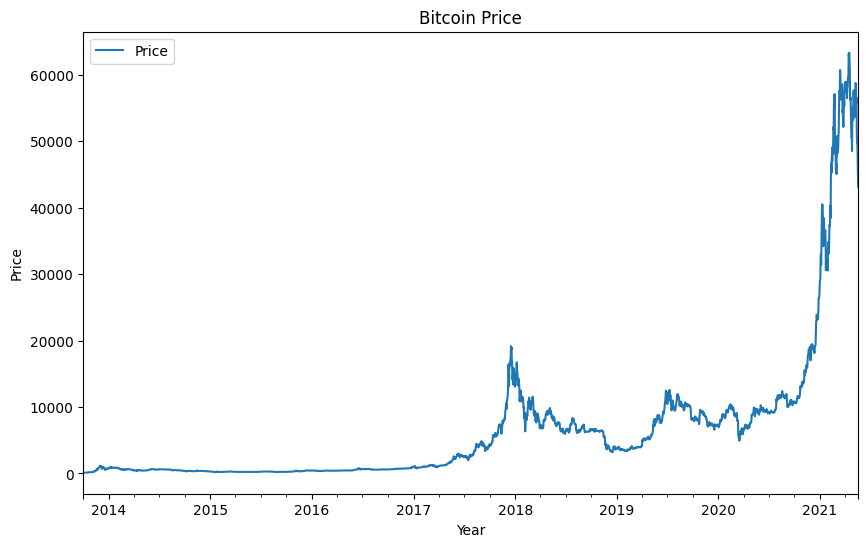

In [11]:
# Plotting The Data:
import matplotlib.pyplot as plt
bitcoin_prices.plot(figsize= (10,6))
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Bitcoin Price')
plt.show()

### Importing time series data with Python's CSV module

If your time series data comes in CSV form you don't necessarily have to use pandas.

You can use Python's [in-built `csv` module](https://docs.python.org/3/library/csv.html). And if you're working with dates, you might also want to use Python's [`datetime`](https://docs.python.org/3/library/datetime.html).

Let's see how we can replicate the plot we created before except this time using Python's `csv` and `datetime` modules.

Resource:
For a great guide on using Python's `csv` module, check out Real Python's tutorial on [Reading and Writing CSV files in Python](https://realpython.com/python-csv/).

In [12]:
# Importing and formatting historical Bitcoin data with Python:
import csv
from datetime import datetime

timesteps= []
btc_price= []

with open('BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv', mode= 'r') as f:
    csv_reader = csv.reader(f, delimiter= ',') # read in the target CSV
    next(csv_reader) # skip first line (this gets rid of the column titles)
    for line in csv_reader:
        timesteps.append(datetime.strptime(line[1], '%Y-%m-%d')) # get the dates as dates (not strings), strptime = string parse time
        btc_price.append(float(line[2])) # get the closing price as float

# View first 10 of each date and data:
timesteps[:10], btc_price[:10]

([datetime.datetime(2013, 10, 1, 0, 0),
  datetime.datetime(2013, 10, 2, 0, 0),
  datetime.datetime(2013, 10, 3, 0, 0),
  datetime.datetime(2013, 10, 4, 0, 0),
  datetime.datetime(2013, 10, 5, 0, 0),
  datetime.datetime(2013, 10, 6, 0, 0),
  datetime.datetime(2013, 10, 7, 0, 0),
  datetime.datetime(2013, 10, 8, 0, 0),
  datetime.datetime(2013, 10, 9, 0, 0),
  datetime.datetime(2013, 10, 10, 0, 0)],
 [123.65499,
  125.455,
  108.58483,
  118.67466,
  121.33866,
  120.65533,
  121.795,
  123.033,
  124.049,
  125.96116])

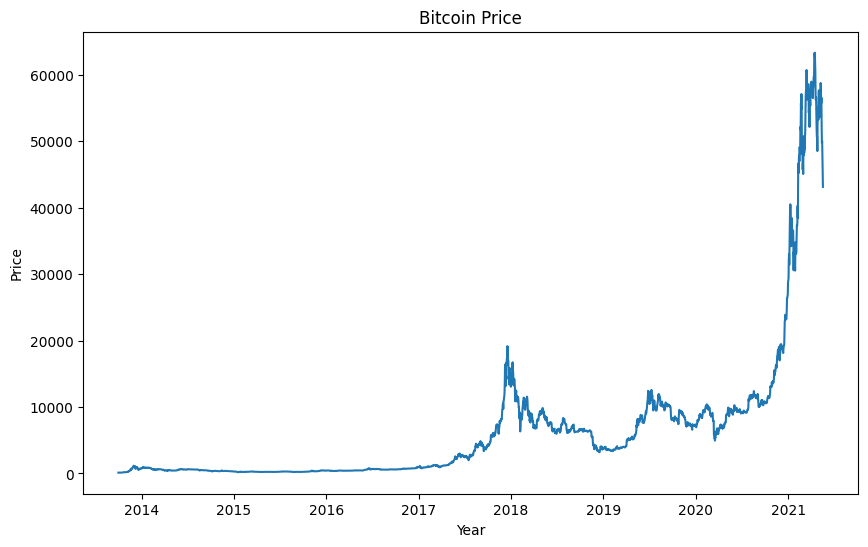

In [13]:
# Plotting The Data:
plt.figure(figsize= (10,6))
plt.plot(timesteps, btc_price)
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Bitcoin Price')
plt.show()

## Format Data Part 1: Creatining train and test sets for time series data


How about creating train and test splits?

Usually, you could create a train and test split using a function like Scikit-Learn's outstanding [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) but as we'll see in a moment, this doesn't really cut it for time series data.

But before we do create splits, it's worth talking about what *kind* of data we have.

In time series problems, you'll either have **univariate** or **multivariate** data.

Can you guess what our data is?

* **Univariate** time series data deals with *one* variable, for example, using the price of Bitcoin to predict the price of Bitcoin.
* **Multivariate** time series data deals with *more than one* variable, for example, predicting electricity demand using the day of week, time of year and number of houses in a region.

![comparison of univariate and multivariate time series data](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-univariate-and-multivariate-time-series-data.png)
*Example of univariate and multivariate time series data. Univariate involves using the target to predict the target. Multivariate inolves using the target as well as another time series to predict the target.*

### Create train & test sets for time series (the wrong way)

We've figured out we're dealing with a univariate time series, so we only have to make a split on one variable (for multivariate time series, you will have to split multiple variables). 

How about we first see the *wrong way* for splitting time series data?

Let's turn our DataFrame index and column into NumPy arrays.

In [14]:
# Getting Data and Price into Arrays:
timesteps = bitcoin_prices.index.to_numpy()
prices = bitcoin_prices['Price'].to_numpy()

In [15]:
timesteps[:10], prices[:10]

(array(['2013-10-01T00:00:00.000000000', '2013-10-02T00:00:00.000000000',
        '2013-10-03T00:00:00.000000000', '2013-10-04T00:00:00.000000000',
        '2013-10-05T00:00:00.000000000', '2013-10-06T00:00:00.000000000',
        '2013-10-07T00:00:00.000000000', '2013-10-08T00:00:00.000000000',
        '2013-10-09T00:00:00.000000000', '2013-10-10T00:00:00.000000000'],
       dtype='datetime64[ns]'),
 array([123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
        121.795  , 123.033  , 124.049  , 125.96116]))

In [16]:
# Wrong Way to Make Train and Test Datasets for Time Series:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(timesteps,
                                                   prices,
                                                   test_size= 0.2,
                                                   random_state= 42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2229,), (558,), (2229,), (558,))

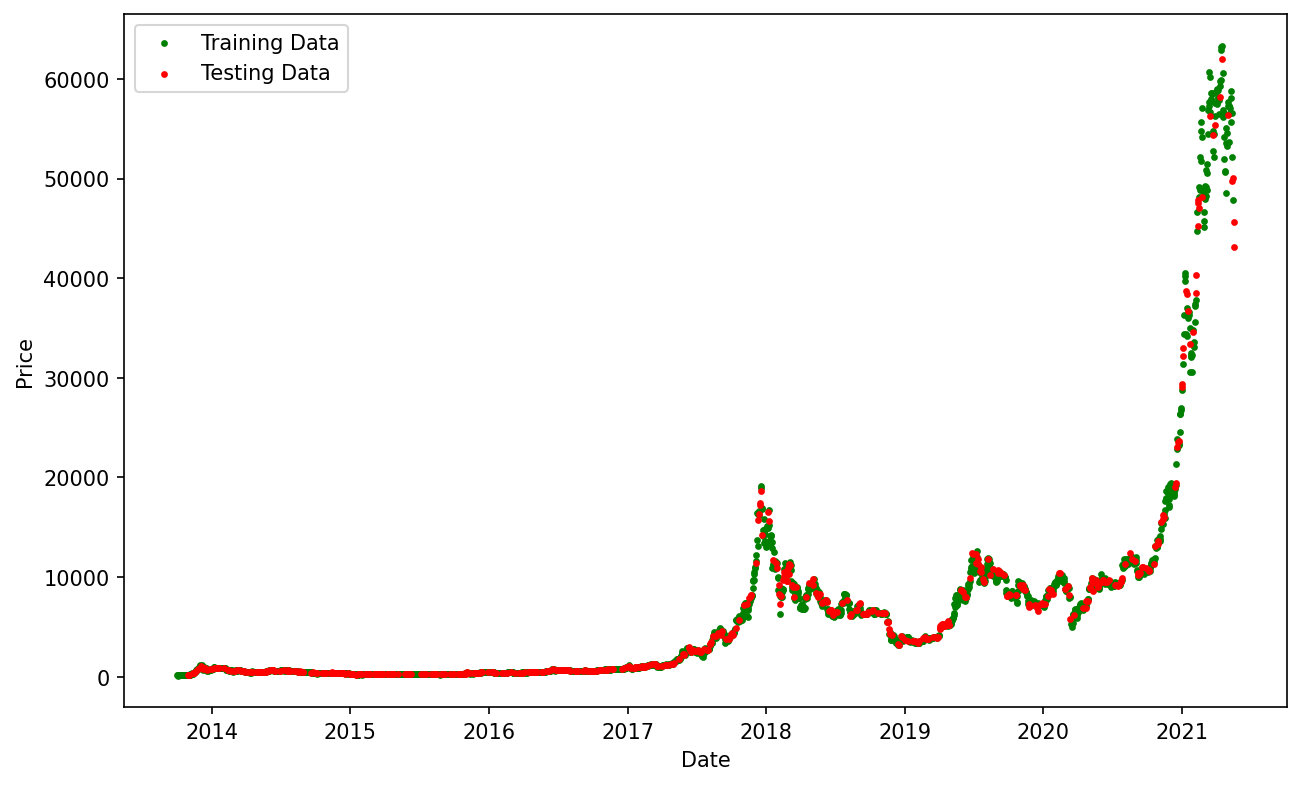

In [18]:
# Plotting Training and Test Data:
plt.figure(figsize= (10,6), dpi= 150)
plt.scatter(X_train, y_train, c= 'green', s=5, label= 'Training Data')
plt.scatter(X_test, y_test, c= 'red', s= 5, label= 'Testing Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

What's wrong with this plot?

Well, let's remind ourselves of what we're trying to do.

We're trying to use the historical price of Bitcoin to predict future prices of Bitcoin.

With this in mind, our seen data (training set) is what?

Prices of Bitcoin in the past.

And our unseen data (test set) is?

Prices of Bitcoin in the future. 

Does the plot above reflect this?

No. 

Our test data is scattered all throughout the training data.

This kind of random split is okay for datasets without a time component (such as images or passages of text for classification problems) but for time series, we've got to take the time factor into account.

To fix this, we've got to split our data in a way that reflects what we're actually trying to do.

We need to split our historical Bitcoin data to have a dataset that reflects the past (train set) and a dataset that reflects the future (test set).

### Create train & test sets for time series (the right way)

There's no way we can actually access data from the future.

But we can engineer our test set to be in the future with respect to the training set.

To do this, we can create an abitrary point in time to split our data.

Everything before the point in time can be considered the training set and everything after the point in time can be considered the test set.

![time series train test split](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-time-series-train-test-split.png)
*Demonstration of time series split. Rather than a traditionaly random train/test split, it's best to split the time series data sequentially. Meaning, the test data should be data from the future when compared to the training data.*

In [19]:
# Creating Trainig and Test Datasets for Time Series (Right Way):
split_size = int(0.8 * len(prices)) # 80% train, 20% test

# Training Data:
X_train, y_train = timesteps[:split_size], prices[:split_size]

# Test Data:
X_test, y_test = timesteps[split_size:], prices[split_size:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2229,), (558,), (2229,), (558,))

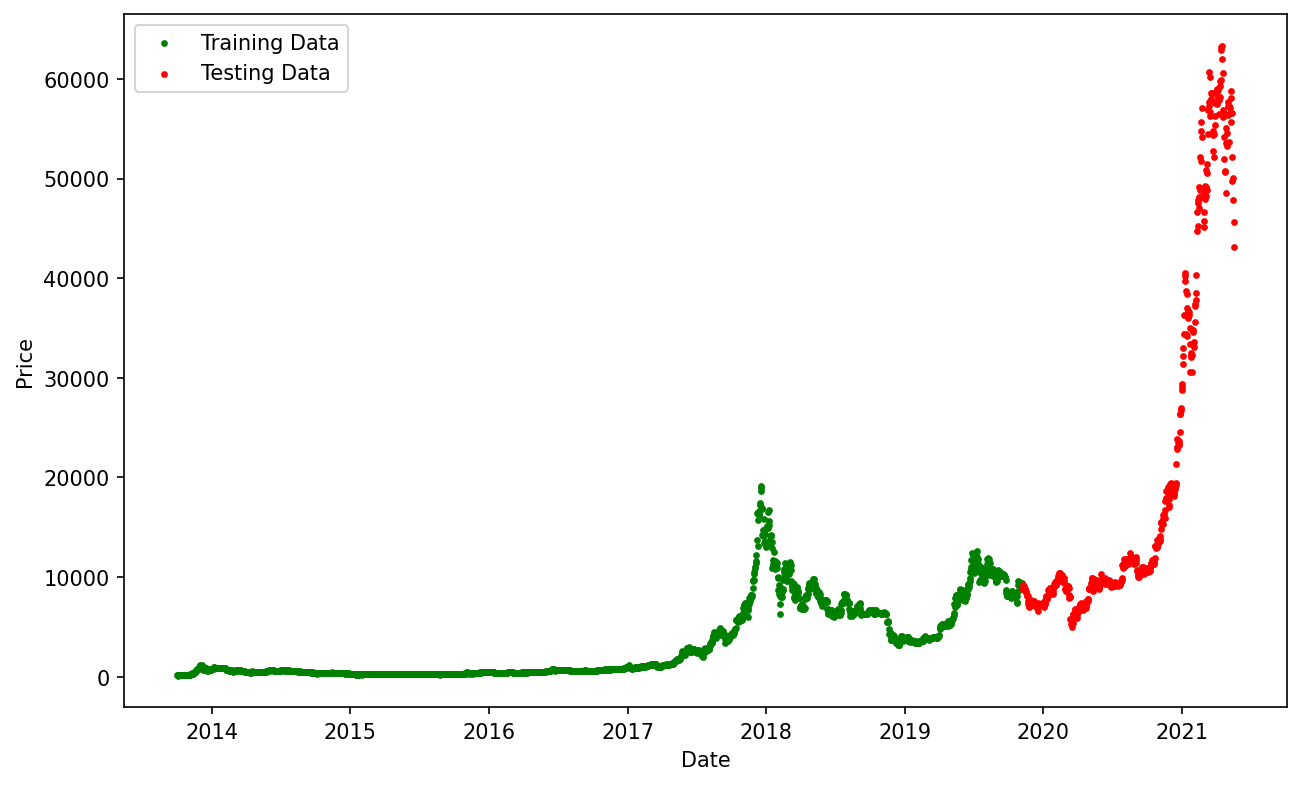

In [20]:
# Plotting Training and Test Data:
plt.figure(figsize= (10,6), dpi= 150)
plt.scatter(X_train, y_train, c= 'green', s=5, label= 'Training Data')
plt.scatter(X_test, y_test, c= 'red', s= 5, label= 'Testing Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

We're going to be using the training set (past) to train a model to try and predict values on the test set (future).

Because the test set is an *artificial* future, we can guage how our model might perform on *actual* future data.

> 🔑 **Note:** The amount of data you reserve for your test set not set in stone. You could have 80/20, 90/10, 95/5 splits or in some cases, you might not even have enough data to split into train and test sets (see the resource below). The point is to remember the test set is a pseudofuture and not the actual future, it is only meant to give you an indication of how the models you're building are performing. 

> 📖 **Resource:** Working with time series data can be tricky compared to other kinds of data. And there are a few pitfalls to watch out for, such as how much data to use for a test set. The article [*3 facts about time series forecasting that surprise experienced machine learning practitioners*](https://towardsdatascience.com/3-facts-about-time-series-forecasting-that-surprise-experienced-machine-learning-practitioners-69c18ee89387) talks about different things to watch out for when working with time series data, I'd recommend reading it.

### Create a plotting function

Rather than retyping `matplotlib` commands to continuously plot data, let's make a plotting function we can reuse later.

In [21]:
# Creating a function to plot time series data:

def plot_time_series(timesteps, values, format= '.', start= 0, end= None, labels= None):
    """
    Plots a timesteps (a series of points in time) against values (a series of values 
    across timesteps).
  
    Parameters
    ---------
    timesteps : array of timesteps
    values : array of values across time
    format : style of plot, default "."
    start : where to start the plot (setting a value will index from start of timesteps & values)
    end : where to end the plot (setting a value will index from end of timesteps & values)
    label : label to show on plot of values
    """

    # Plotting The Time Series:
    plt.plot(timesteps[start:end], values[start:end], format, label= labels)
    plt.xlabel('Date')
    plt.ylabel('Price')
    if labels:
        plt.legend()
    plt.grid(visible= True)

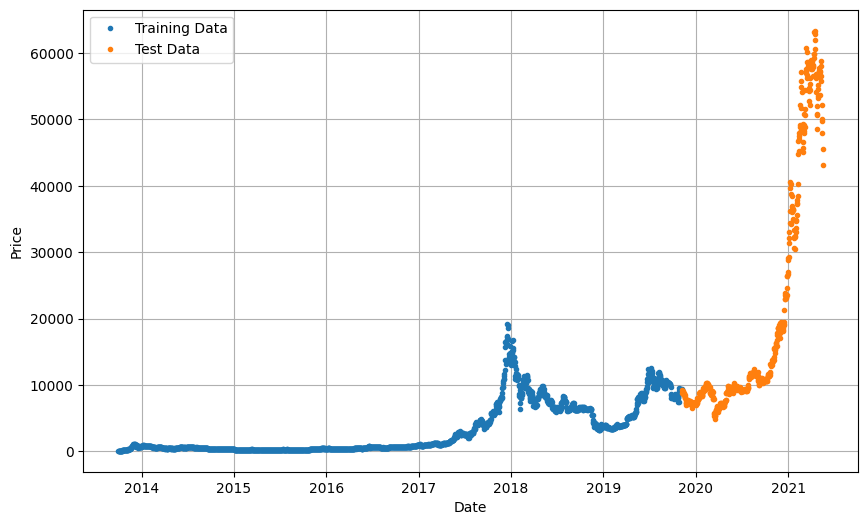

In [22]:
# Testing Out Plotting Function:
plt.figure(figsize= (10,6))
plot_time_series(timesteps= X_train, values= y_train, labels= 'Training Data')
plot_time_series(timesteps= X_test, values= y_test, labels= 'Test Data')

## Modelling Experiments

Before we discuss what modelling experiments we're going to run, there are two terms you should be familiar with, **horizon** and **window**. 
  * **horizon** = number of timesteps to predict into future
  * **window** = number of timesteps from past used to predict **horizon**

For example, if we wanted to predict the price of Bitcoin for tomorrow (1 day in the future) using the previous week's worth of Bitcoin prices (7 days in the past), the horizon would be 1 and the window would be 7.

Modelling Experiments?

| Model Number | Model Type | Horizon size | Window size | Extra data |
| ----- | ----- | ----- | ----- | ----- |
| 0 | Naïve model (baseline) | NA | NA | NA |
| 1 | Dense model | 1 | 7 | NA |
| 2 | Same as 1 | 1 | 30 | NA | 
| 3 | Same as 1 | 7 | 30 | NA |
| 4 | Conv1D | 1 | 7 | NA |
| 5 | LSTM | 1 | 7 | NA |
| 6 | Same as 1 (but with multivariate data) | 1 | 7 | Block reward size |
| 7 | [N-BEATs Algorithm](https://arxiv.org/pdf/1905.10437.pdf) | 1 | 7 | NA |
| 8 | Ensemble (multiple models optimized on different loss functions) | 1 | 7 | NA | 
| 9 | Future prediction model (model to predict future values) | 1 | 7 | NA| 
| 10 | Same as 1 (but with turkey 🦃 data introduced) | 1 | 7 | NA |

Note: To reiterate, as you can see, we can build many types of models for the data we're working with. But that doesn't mean that they'll perform well. Deep learning is a powerful technique but it doesn't always work. And as always, start with a simple model first and then add complexity as needed. 

## Model 0: Naïve forecast (baseline)

One of the most common baseline models for time series forecasting, the naïve model (also called the [naïve forecast](https://otexts.com/fpp3/simple-methods.html#na%C3%AFve-method)), requires no training at all.

That's because all the naïve model does is use the previous timestep value to predict the next timestep value.

The formula looks like this:

$$\hat{y}_{t} = y_{t-1}$$ 

In English: 
> The prediction at timestep `t` (y-hat) is equal to the value at timestep `t-1` (the previous timestep).

In an open system (like a stock market or crypto market), you'll often find beating the naïve forecast with *any* kind of model is quite hard.

Note: For the sake of this notebook, an **open system** is a system where inputs and outputs can freely flow, such as a market (stock or crypto). Where as, a **closed system** the inputs and outputs are contained within the system (like a poker game with your buddies, you know the buy in and you know how much the winner can get). Time series forecasting in **open systems** is generally quite poor.

In [23]:
# Creating Naive Forecast:
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:]

(array([9226.48582088, 8794.35864452, 8798.04205463, 9081.18687849,
        8711.53433917, 8760.89271814, 8749.52059102, 8656.97092235,
        8500.64355816, 8469.2608989 ]),
 array([57107.12067189, 58788.20967893, 58102.19142623, 55715.54665129,
        56573.5554719 , 52147.82118698, 49764.1320816 , 50032.69313676,
        47885.62525472, 45604.61575361]))

In [24]:
y_test[-10:]

array([58788.20967893, 58102.19142623, 55715.54665129, 56573.5554719 ,
       52147.82118698, 49764.1320816 , 50032.69313676, 47885.62525472,
       45604.61575361, 43144.47129086])

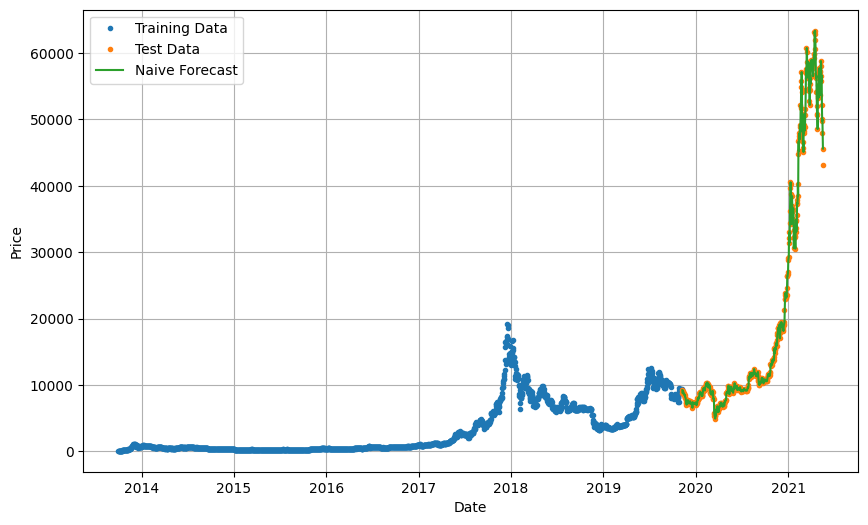

In [25]:
# Plotting Data and Naive Forecast:
plt.figure(figsize= (10,6))
plot_time_series(timesteps= X_train, values= y_train, labels= 'Training Data')
plot_time_series(timesteps= X_test, values= y_test, labels= 'Test Data')
plot_time_series(timesteps= X_test[1:], values= naive_forecast, format= '-', labels= 'Naive Forecast')

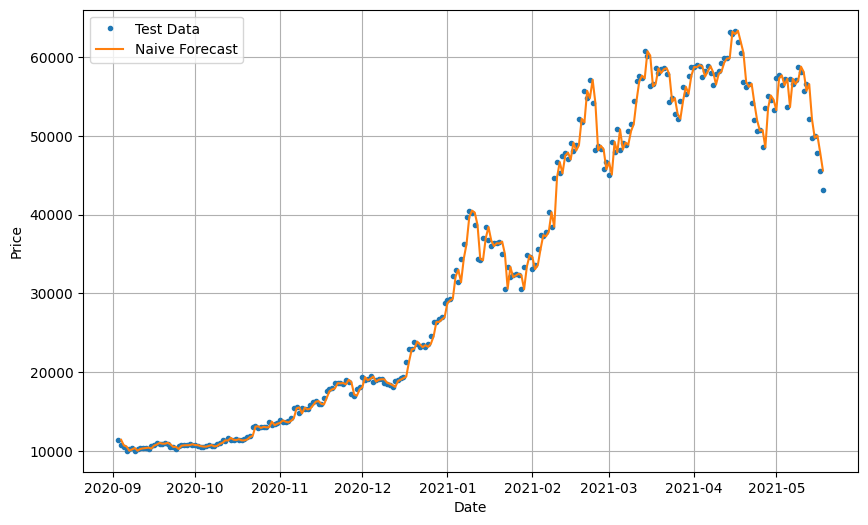

In [26]:
# Zooming in On Test Data and Forecasts:
plt.figure(figsize=(10, 6))
offset = 300 # offset the values by 300 timesteps 
plot_time_series(timesteps=X_test, values=y_test, start=offset, labels='Test Data')
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format='-', start=offset, labels='Naive Forecast')

## Evaluating a time series model

Time series forecasting often involves predicting a number (in our case, the price of Bitcoin).

With this known, we can use regression evaluation metrics to evaluate our time series forecasts.

The main thing we will be evaluating is: **how do our model's predictions (`y_pred`) compare against the actual values (`y_true` or *ground truth values*)**? 

Resource: We're going to be using several metrics to evaluate our different model's time series forecast accuracy. Many of them are sourced and explained mathematically and conceptually in [Forecasting: Principles and Practice chapter 5.8](https://otexts.com/fpp3/accuracy.html).

For all of the following metrics, **lower is better** (for example an MAE of 0 is better than an MAE 100).

### Scale-dependent errors

These are metrics which can be used to compare time series values and forecasts that are on the same scale.

For example, Bitcoin historical prices in USD veresus Bitcoin forecast values in USD.

| Metric | Details | Code |
| ----- | ----- | ----- |
| **MAE** (mean absolute error) | Easy to interpret (a forecast is X amount different from actual amount). Forecast methods which minimises the MAE will lead to forecasts of the median. | [`tf.keras.metrics.mean_absolute_error()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/MeanAbsoluteError) |
| **RMSE** (root mean square error) | Forecasts which minimise the RMSE lead to forecasts of the mean. | `tf.sqrt(`[`tf.keras.metrics.mean_square_error()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/RootMeanSquaredError)`)`|

### Percentage errors

Percentage errors do not have units, this means they can be used to compare forecasts across different datasets.

| **Metric** | **Details** | **Code** |
| ----- | ----- | ----- |
| **MAPE** (mean absolute percentage error) | Most commonly used percentage error. May explode (not work) if `y=0`. | [`tf.keras.metrics.mean_absolute_percentage_error()`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/MAPE) | 
| **sMAPE** (symmetric mean absolute percentage error) | Recommended not to be used by [Forecasting: Principles and Practice](https://otexts.com/fpp3/accuracy.html#percentage-errors), though it is used in forecasting competitions. | Custom implementation |

### Scaled errors

Scaled errors are an alternative to percentage errors when comparing forecast performance across different time series.

| **Metric** | **Details** | **Code** |
| ----- | ----- | ----- |
| **MASE** (mean absolute scaled error). | MASE equals one for the naive forecast (or very close to one). A forecast which performs better than the naïve should get <1 MASE. | See sktime's [`mase_loss()`](https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16) |

Question: There are so many metrics... which one should I pay most attention to? It's going to depend on your problem. However, since its ease of interpretation, MAE is often a very good place to start.

Since we're going to be evaluing a lot of models, let's write a function to help us calculate evaluation metrics on their forecasts.

In [27]:
import tensorflow as tf

2026-03-05 12:43:52.359058: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 12:43:53.209420: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 12:43:54.901241: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [28]:
# MASE Implementation 
# sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16

def mean_absolute_scaled_error(y_true, y_pred):
    """
    Implement MASE (assuming no seasonality of data).
    """

    mae = tf.reduce_mean(tf.abs(y_true - y_pred))

    # MAE of Naive Forecast (No Seasonality):
    mae_naive_no_seasonality = tf.reduce_mean(tf.abs((y_true[1:] - y_true[:-1]))) # our seasonality is 1 day (hence the shifting of 1 day)


    return mae / mae_naive_no_seasonality

You'll notice the version of MASE above doesn't take in the training values like sktime's `mae_loss()`. In our case, we're comparing the MAE of our predictions on the test to the MAE of the naïve forecast on the test set.

In practice, if we've created the function correctly, the naïve model should achieve an MASE of 1 (or very close to 1). Any model worse than the naïve forecast will achieve an MASE of >1 and any model better than the naïve forecast will achieve an MASE of <1.

Let's put each of our different evaluation metrics together into a function.

In [29]:
# Creating a Function to take in True Values and Model Predictions and Return Evaluation Metrics:

def evaluate_preds(y_true, y_pred):

    # Make sure float32 (for metric calculations):
    y_true = tf.cast(y_true, dtype= tf.float32)
    y_pred = tf.cast(y_pred, dtype= tf.float32)

    # Calculating Various Metrics:
    mae = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
    mse = tf.keras.metrics.mean_squared_error(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        'mae': mae.numpy(),
        'mse': mse.numpy(),
        'rmse': rmse.numpy(),
        'mape': mape.numpy(),
        'mase': mase.numpy()
    }

In [30]:
# Calculating Evaluation Metrics for naive Forecast Model:
naive_results = evaluate_preds(y_true= y_test[1:],
                              y_pred= naive_forecast)
naive_results

I0000 00:00:1772714635.976582     666 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


{'mae': 567.9802,
 'mse': 1147547.0,
 'rmse': 1071.2362,
 'mape': 2.516525,
 'mase': 0.99957}

Taking a look at the naïve forecast's MAE, it seems on average each forecast is ~$567 different than the actual Bitcoin price.

How does this compare to the average price of Bitcoin in the test dataset?

In [31]:
# Find Average Price of Bitcoin in Test Dataset:
tf.reduce_mean(y_test).numpy()

20056.632963737222

In [32]:
tf.reduce_min(y_test).numpy(), tf.reduce_max(y_test).numpy()

(4944.7023359837, 63346.7890351052)

Okay, looking at these two values is starting to give us an idea of how our model is performing:
* The average price of Bitcoin in the test dataset is: $20,056 (note: average may not be the best measure here, since the highest price is over 3x this value and the lowest price is over 4x lower)

* Each prediction in naive forecast is on average off by: $567

Is this enough to say it's a good model?

That's up your own interpretation.

## Other kinds of time series forecasting models which can be used for baselines and actual forecasts

Since we've got a naïve forecast baseline to work with, it's time we start building models to try and beat it.

And because this file is focused on TensorFlow and deep learning, we're going to be using TensorFlow to build deep learning models to try and improve on our naïve forecasting results.

That being said, there are many other kinds of models you may want to look into for building baselines/performing forecasts.

Some of them may even beat our best performing models in this notebook. [Some of which are intlempented here using Scikit-Learn Library](<https://github.com/Shailya-Ds-Or/Machine-Learning/tree/main/10)%20Time%20Series%20Analysis%20and%20Modeling>)

| **Model/Library Name** | **Resource** |
| ----- | ----- |
| Moving average | https://machinelearningmastery.com/moving-average-smoothing-for-time-series-forecasting-python/ |
| ARIMA (Autoregression Integrated Moving Average) | https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/ |
| sktime (Scikit-Learn for time series) | https://github.com/alan-turing-institute/sktime |
| TensorFlow Decision Forests (random forest, gradient boosting trees) | https://www.tensorflow.org/decision_forests |
| Facebook Kats (purpose-built forecasting and time series analysis library by Facebook) | https://github.com/facebookresearch/Kats | 
| LinkedIn Greykite (flexible, intuitive and fast forecasts) | https://github.com/linkedin/greykite |

## Format Data Part 2: Windowing dataset

We've got to window our time series.

Why do we window?

Windowing is a method to turn a time series dataset into **supervised learning problem**. 

In other words, we want to use windows of the past to predict the future.

For example for a univariate time series, windowing for one week (`window=7`) to predict the next single value (`horizon=1`) might look like:

```
Window for one week (univariate time series)

[0, 1, 2, 3, 4, 5, 6] -> [7]
[1, 2, 3, 4, 5, 6, 7] -> [8]
[2, 3, 4, 5, 6, 7, 8] -> [9]
```

Or for the price of Bitcoin, it'd look like:

```
Window for one week with the target of predicting the next day (Bitcoin prices)

[123.654, 125.455, 108.584, 118.674, 121.338, 120.655, 121.795] -> [123.033]
[125.455, 108.584, 118.674, 121.338, 120.655, 121.795, 123.033] -> [124.049]
[108.584, 118.674, 121.338, 120.655, 121.795, 123.033, 124.049] -> [125.961]
```

![windows and horizons for turning time series data into a supervised learning problem](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-time-series-windows-and-horizons.png)
*Example of windows and horizons for Bitcoin data. Windowing can be used to turn time series data into a supervised learning problem.*

Let's build some functions which take in a univariate time series and turn it into windows and horizons of specified sizes.

We'll start with the default horizon size of 1 and a window size of 7 (these aren't necessarily the best values to use).

In [33]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

In [34]:
# Creating a Function tp Label Windowed Data:
def get_labeled_windows(x, horizon= 1):
    """
    Creates labels for windowed dataset.

    E.g. if horizon=1 (default)
    Input: [0, 1, 2, 3, 4, 5, 6, 7] -> Output: ([0, 1, 2, 3, 4, 5, 6], [7])
    """
    return (x[:, :-horizon], x[:, -horizon:])

In [35]:
# Testing out The Window Labelling Function:
test_window, test_label = get_labeled_windows(tf.expand_dims(tf.range(8), axis= 0), horizon= HORIZON)

In [36]:
test_window, test_label

(<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[0, 1, 2, 3, 4, 5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[7]], dtype=int32)>)

Now we need a way to make windows for an entire time series.

We could do this with Python for loops, however, for large time series, that'd be quite slow.

To speed things up, we'll leverage [NumPy's array indexing](https://numpy.org/doc/stable/reference/arrays.indexing.html).

Let's write a function which:
1. Creates a window step of specific window size, for example: `[[0, 1, 2, 3, 4, 5, 6, 7]]`
2. Uses NumPy indexing to create a 2D of multiple window steps, for example: 
```
[[0, 1, 2, 3, 4, 5, 6, 7],
 [1, 2, 3, 4, 5, 6, 7, 8],
 [2, 3, 4, 5, 6, 7, 8, 9]]
```
3. Uses the 2D array of multuple window steps to index on a target series
4. Uses the `get_labelled_windows()` function we created above to turn the window steps into windows with a specified horizon

Resource: The function created below has been adapted from Syafiq Kamarul Azman's article [*Fast and Robust Sliding Window Vectorization with NumPy*](https://towardsdatascience.com/fast-and-robust-sliding-window-vectorization-with-numpy-3ad950ed62f5).

In [37]:
import numpy as np

In [38]:
# Creating a Function to View Numpy Arrays as Windows:
def make_windows(x, window_size= 7, horizon= 1):
    """
    Turns a 1D array into a 2D array of sequential windows of window_size.
    """

    # 1. Create a window of specific window_size (add the horizon on the end for later labelling):
    window_step = np.expand_dims(np.arange(window_size + horizon), axis= 0)
    #print(f"Window step:\n {window_step}")

    # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing):
    window_indexes = window_step + np.expand_dims(np.arange(len(x) - (window_size + horizon - 1)), axis= 0).T
    #print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

    # 3. Index on the target array (time series) with 2D array of multiple window steps:
    windowed_array = x[window_indexes]

    # 4. get The Labeled Windows:
    windows, labels = get_labeled_windows(windowed_array, horizon= horizon)

    return windows, labels

In [39]:
full_windows, full_labels = make_windows(prices, window_size= 7, horizon= 1)
full_windows.shape, full_labels.shape

((2780, 7), (2780, 1))

In [40]:
full_windows[:3]

array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
        121.795  ],
       [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
        123.033  ],
       [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
        124.049  ]])

In [41]:
full_labels[:3]

array([[123.033  ],
       [124.049  ],
       [125.96116]])

In [42]:
# View the first 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i]} -> Label: {full_labels[i]}")

Window: [123.65499 125.455   108.58483 118.67466 121.33866 120.65533 121.795  ] -> Label: [123.033]
Window: [125.455   108.58483 118.67466 121.33866 120.65533 121.795   123.033  ] -> Label: [124.049]
Window: [108.58483 118.67466 121.33866 120.65533 121.795   123.033   124.049  ] -> Label: [125.96116]


In [43]:
# View the last 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i-3]} -> Label: {full_labels[i-3]}")

Window: [58788.20967893 58102.19142623 55715.54665129 56573.5554719
 52147.82118698 49764.1320816  50032.69313676] -> Label: [47885.62525472]
Window: [58102.19142623 55715.54665129 56573.5554719  52147.82118698
 49764.1320816  50032.69313676 47885.62525472] -> Label: [45604.61575361]
Window: [55715.54665129 56573.5554719  52147.82118698 49764.1320816
 50032.69313676 47885.62525472 45604.61575361] -> Label: [43144.47129086]


> 🔑 **Note:** You can find a function which achieves similar results to the ones we implemented above at [`tf.keras.preprocessing.timeseries_dataset_from_array()`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array). Just like ours, it takes in an array and returns a windowed dataset. It has the benefit of returning data in the form of a tf.data.Dataset instance (we'll see how to do this with our own data later).

## Turning windows into training and test sets 

Time to turn our windows into training and test splits.

We could've windowed our existing training and test splits, however, with the nature of windowing (windowing often requires an offset at some point in the data), it usually works better to window the data first, then split it into training and test sets.

Let's write a function which takes in full sets of windows and their labels and splits them into train and test splits.

In [44]:
# Making Train Test Split:
def make_train_test_splits(windows, labels, test_spilt= 0.2):
    """
    Splits matching pairs of windows and labels into train and test splits.
    """
    split_size = int(len(windows) * (1 - test_spilt)) # this will default to 80% train/20% test
    train_windows = windows[:split_size]
    train_labels = labels[:split_size]
    test_windows = windows[split_size:]
    test_labels = labels[split_size:]

    return train_windows, test_windows, train_labels, test_labels

In [45]:
# Creating Training and Test Windows and Labels:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows= full_windows,
                                                                               labels= full_labels,
                                                                               test_spilt= 0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2224, 556, 2224, 556)

In [46]:
train_windows[:5], train_labels[:5]

(array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
         121.795  ],
        [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
         123.033  ],
        [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
         124.049  ],
        [118.67466, 121.33866, 120.65533, 121.795  , 123.033  , 124.049  ,
         125.96116],
        [121.33866, 120.65533, 121.795  , 123.033  , 124.049  , 125.96116,
         125.27966]]),
 array([[123.033  ],
        [124.049  ],
        [125.96116],
        [125.27966],
        [125.9275 ]]))

In [47]:
test_windows[:5], test_labels[:5]

(array([[9290.89660239, 9202.41545055, 9369.62808116, 9326.59962378,
         9335.75240233, 9226.48582088, 8794.35864452],
        [9202.41545055, 9369.62808116, 9326.59962378, 9335.75240233,
         9226.48582088, 8794.35864452, 8798.04205463],
        [9369.62808116, 9326.59962378, 9335.75240233, 9226.48582088,
         8794.35864452, 8798.04205463, 9081.18687849],
        [9326.59962378, 9335.75240233, 9226.48582088, 8794.35864452,
         8798.04205463, 9081.18687849, 8711.53433917],
        [9335.75240233, 9226.48582088, 8794.35864452, 8798.04205463,
         9081.18687849, 8711.53433917, 8760.89271814]]),
 array([[8798.04205463],
        [9081.18687849],
        [8711.53433917],
        [8760.89271814],
        [8749.52059102]]))

In [48]:
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((2224, 7), (556, 7), (2224, 1), (556, 1))

In [49]:
# Check to see if same (accounting for horizon and window size):
np.array_equal(np.squeeze(train_labels[:-HORIZON-1]), y_train[WINDOW_SIZE:])

True

## Make a modelling checkpoint

Because our model's performance will fluctuate from experiment to experiment, we'll want to make sure we're comparing apples to apples.

What I mean by this is in order for a fair comparison, we want to compare each model's best performance against each model's best performance.

For example, if `model_1` performed incredibly well on epoch 55 but its performance fell off toward epoch 100, we want the version of the model from epoch 55 to compare to other models rather than the version of the model from epoch 100.

And the same goes for each of our other models: compare the best against the best.

To take of this, we'll implement a [`ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) callback.

The `ModelCheckpoint` callback will monitor our model's performance during training and save the best model to file by setting `save_best_only=True`.

That way when evaluating our model we could restore its best performing configuration from file.

> 🔑 **Note:** Because of the size of the dataset (smaller than usual), you'll notice our modelling experiment results fluctuate quite a bit during training (hence the implementation of the `ModelCheckpoint` callback to save the best model).

Because we're going to be running multiple experiments, it makes sense to keep track of them by saving models to file under different names.

To do this, we'll write a small function to create a `ModelCheckpoint` callback which saves a model to specified filename.

In [50]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename:
def create_model_checkpoint(model_name, save_path= 'time_series_model_experiments'):
    return tf.keras.callbacks.ModelCheckpoint(filepath= os.path.join(save_path, model_name+''+'.keras'), # create filepath to save model
                                             save_best_only= True, # save only the best model to file
                                             verbose= 0) # only output a limited amount of text  

## Model 1: Dense model (window = 7, horizon = 1)

Time to build one of our models.

Often, preparing data for a model is one of the largest parts of any machine learning project.

And once you've got a good model in place, you'll probably notice far more improvements from manipulating the data (e.g. collecting more, improving the quality) than manipulating the model.

We're going to start by keeping it simple, `model_1` will have:
* A single dense layer with 128 hidden units and ReLU (rectified linear unit) activation
* An output layer with linear activation (or no activation)
* Adam optimizer and MAE loss function
* Batch size of 128
* 100 epochs


A batch size of 32 works pretty well too and we could always train for less epochs but since the model runs so fast (you'll see in a second, it's because the number of samples we have isn't massive) we might as well train for more.

> 🔑 **Note:** As always, many of the values for machine learning problems are experimental. A reminder that the values you can set yourself in a machine learning algorithm (the hidden units, the batch size, horizon size, window size) are called [**hyperparameters**](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning). And experimenting to find the best values for hyperparameters is called **hyperparameter tuning**. Where as parameters learned by a model itself (patterns in the data, formally called weights & biases) are referred to as **parameters**.

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Lambda, Conv1D, LSTM, Input, add, subtract
from tensorflow.keras.metrics import mae
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [52]:
# Setting Random Seed:
tf.random.set_seed(42)

# Creating Model:
model_1 = Sequential(name= 'Model_1_Dense')
model_1.add(Dense(units= 128, activation= 'relu'))
model_1.add(Dense(units= HORIZON, activation= 'linear')) # linear activation is the same as having no activation

# Compiling The Model:
model_1.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_1_history = model_1.fit(x= train_windows,
                             y= train_labels,
                             epochs= 100,
                             batch_size= 128,
                             validation_data= (test_windows, test_labels),
                             callbacks= [create_model_checkpoint(model_name= model_1.name)])

Epoch 1/100


2026-03-05 12:43:57.705048: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a0212117480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-05 12:43:57.705072: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-03-05 12:43:57.723217: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-05 12:43:57.759705: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
I0000 00:00:1772714637.851090     791 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 [==============================] - 1s 10ms/step - loss: 2193.9619 - mae: 2193.9619 - val_loss: 2459.9226 - val_mae: 2459.9226
Epoch 2/100
18/18 [==============================] - 0s 4ms/step - loss: 345.4189 - mae: 345.4189 - val_loss: 1410.4741 - val_mae: 1410.4741
Epoch 3/100
18/18 [==============================] - 0s 4ms/step - loss: 226.2203 - mae: 226.2203 - val_loss: 1048.6495 - val_mae: 1048.6495
Epoch 4/100
18/18 [==============================] - 0s 4ms/step - loss: 190.8347 - mae: 190.8347 - val_loss: 1036.4557 - val_mae: 1036.4557
Epoch 5/100
18/18 [==============================] - 0s 3ms/step - loss: 186.0242 - mae: 186.0242 - val_loss: 1043.6309 - val_mae: 1043.6309
Epoch 6/100
18/18 [==============================] - 0s 4ms/step - loss: 182.8829 - mae: 182.8829 - val_loss: 1029.7430 - val_mae: 1029.7430
Epoch 7/100
18/18 [==============================] - 0s 4ms/step - loss: 181.7325 - mae: 181.7325 - val_loss: 984.3264 - val_mae: 984.3264
Epoch 8/100
18/18 [=====

In [53]:
# Evaluating Model on Test Data:
model_1.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 605.1795 - mae: 605.1795


[605.1795043945312, 605.1795043945312]

In [54]:
# Load in saved best performing model_1 and evaluate on test data:
model_1 = tf.keras.models.load_model('time_series_model_experiments/Model_1_Dense.keras')
model_1.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 564.8221 - mae: 564.8221


[564.8221435546875, 564.8221435546875]

## Making forecasts with a model (on the test dataset)

We've trained a model and evaluated the it on the test data, but the project we're working on is called BitPredict 💰📈 so how do you think we could use our model to make predictions?

Since we're going to be running more modelling experiments, let's write a function which: 
1. Takes in a trained model (just like `model_1`)
2. Takes in some input data (just like the data the model was trained on) 
3. Passes the input data to the model's `predict()` method
4. Returns the predictions.

In [55]:
def make_preds(model, input_data):
    """
    Uses model to make predictions on input_data.

    Parameters
    ----------
    model: trained model 
    input_data: windowed input data (same kind of data model was trained on)

    Returns model predictions on input_data.
    """
    forecast = model.predict(input_data)
    return tf.squeeze(forecast) # returns 1D array of predictions

In [56]:
# Making Predictions Using Model 1 on Test Data:
model_1_preds = make_preds(model= model_1,
                          input_data= test_windows)
model_1_preds[:10], len(model_1_preds)

18/18 [==============================] - 0s 1ms/step


(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8856.281, 8775.718, 8997.728, 8767.436, 8766.576, 8731.627,
        8657.837, 8533.631, 8455.783, 8511.38 ], dtype=float32)>,
 556)

|> 🔑 **Note:** With these outputs, our model isn't *forecasting* yet. It's only making predictions on the test dataset. Forecasting would involve a model making predictions into the future, however, the test dataset is only a pseudofuture.

In [57]:
# Calculating Metrics for Model 1:
model_1_results = evaluate_preds(y_true= tf.squeeze(test_labels),
                                y_pred= model_1_preds)
model_1_results

{'mae': 564.8221,
 'mse': 1162663.0,
 'rmse': 1078.2686,
 'mape': 2.531173,
 'mase': 0.99223596}

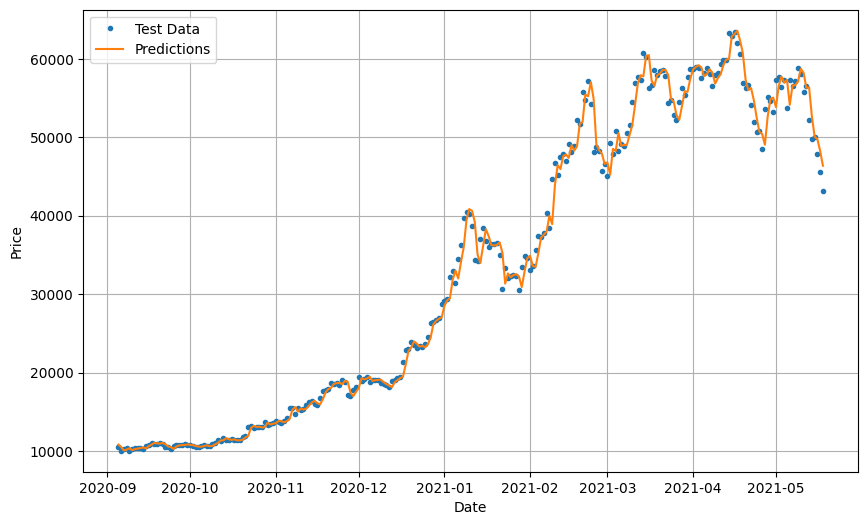

In [58]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (10,6))
plot_time_series(timesteps=X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):], values= model_1_preds, start= offset, format= '-', labels= 'Predictions')

## Model 2: Dense (window = 30, horizon = 1)


We'll keep the previous model architecture but use a window size of 30.

In other words, we'll use the previous 30 days of Bitcoin prices to try and predict the next day price.

![bitcoin prices windowed for 30 days to predict a horizon of 1 day](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-bitcoin-price-window-for-one-month.png)
*Example of Bitcoin prices windowed for 30 days to predict a horizon of 1.*

> 🔑 **Note:** Recall from before, the window size (how many timesteps to use to fuel a forecast) and the horizon (how many timesteps to predict into the future) are **hyperparameters**. This means you can tune them to try and find values will result in better performance.

We'll start our second modelling experiment by preparing datasets using the functions we created earlier.

In [59]:
HORIZON = 1 # predict one step at a time
WINDOW_SIZE = 30 # Use 30 timesteps in the past

In [60]:
# Making Windowed Data and Labels with New Window and Horizon Sizes:
full_windows, full_labels = make_windows(x= prices,
                                        window_size= WINDOW_SIZE,
                                        horizon= HORIZON)
full_windows.shape, full_labels.shape

((2757, 30), (2757, 1))

In [61]:
# Making Train and Test Split Datasets:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows= full_windows,
                                                                               labels= full_labels,
                                                                               test_spilt= 0.2)
train_windows.shape, test_windows.shape, train_windows.shape, train_labels.shape

((2205, 30), (552, 30), (2205, 30), (2205, 1))

In [62]:
# Creating Model:
tf.random.set_seed(42)

model_2 = Sequential(name= 'Model_2_Dense')
model_2.add(Dense(units= 128, activation= 'relu'))
model_2.add(Dense(units= HORIZON, activation= 'linear'))

# Compiling The Model:
model_2.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_2_history = model_2.fit(x= train_windows,
                             y= train_labels,
                             epochs= 100,
                             batch_size= 128,
                             verbose= 0,
                             validation_data= (test_windows, test_labels),
                             callbacks= [create_model_checkpoint(model_name= model_2.name)])

In [63]:
# Evaluating Model 2 on Test Data:
model_2.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 608.1466 - mae: 608.1466


[608.1466064453125, 608.1466064453125]

In [64]:
# Load in saved best performing model_2 and evaluate on test data:
model_2 = tf.keras.models.load_model("time_series_model_experiments/Model_2_Dense.keras")
model_2.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 3ms/step - loss: 607.1338 - mae: 607.1338


[607.1337890625, 607.1337890625]

In [65]:
# Get Predictions on Test Data:
model_2_preds = make_preds(model_2, test_windows)
model_2_preds[:10]

18/18 [==============================] - 0s 2ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8770.083 , 8704.531 , 8691.737 , 8637.66  , 8504.864 , 8436.972 ,
       8226.86  , 8027.7666, 8055.0063, 7780.461 ], dtype=float32)>

In [66]:
# Calculating Metrics for Model 2:
model_2_results= evaluate_preds(y_true= tf.squeeze(test_labels),
                               y_pred= model_2_preds)
model_2_results

{'mae': 607.1338,
 'mse': 1298936.4,
 'rmse': 1139.7089,
 'mape': 2.7493923,
 'mase': 1.0612758}

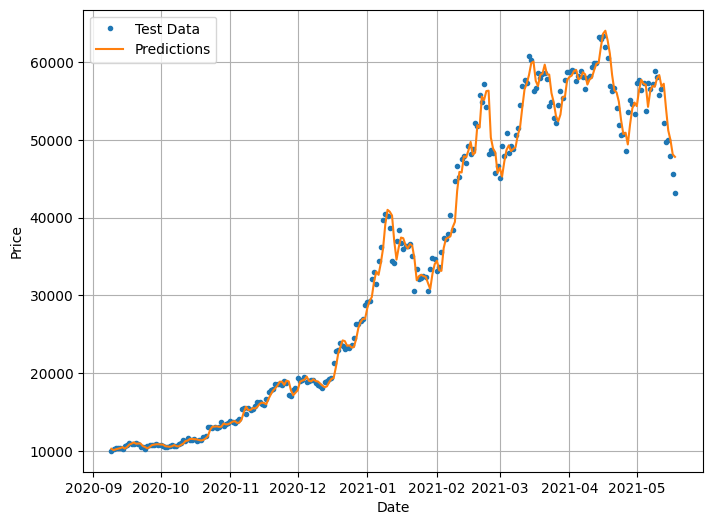

In [67]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (8,6))
plot_time_series(timesteps= X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):], values= model_2_preds, start= offset, format= '-', labels= 'Predictions')

## Model 3: Dense (window = 30, horizon = 7)

Let's try and predict 7 days ahead given the previous 30 days.

First, we'll update the `HORIZON` and `WINDOW_SIZE` variables and create windowed data.

In [68]:
HORIZON = 7
WINDOW_SIZE = 30

In [69]:
full_windows, full_labels = make_windows(x= prices, window_size= WINDOW_SIZE, horizon= HORIZON)
full_windows.shape, full_labels.shape

((2751, 30), (2751, 7))

In [70]:
train_windows, test_windows, train_labels, test_labels= make_train_test_splits(windows= full_windows,
                                                                              labels= full_labels,
                                                                              test_spilt= 0.2)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((2200, 30), (551, 30), (2200, 7), (551, 7))

In [71]:
# Creating The Model:

tf.random.set_seed(42)

model_3 = Sequential(name= 'Model_3_Dense')
model_3.add(Dense(units= 128, activation= "relu"))
model_3.add(Dense(units= HORIZON, activation= "linear"))

# Compiling The Model:
model_3.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_3_history = model_3.fit(x= train_windows,
                             y= train_labels,
                             validation_data= (test_windows, test_labels),
                             epochs= 100,
                             batch_size= 128,
                             callbacks= [create_model_checkpoint(model_name= model_3.name)])

Epoch 1/100
18/18 [==============================] - 1s 11ms/step - loss: 1756.7236 - mae: 1756.7236 - val_loss: 2758.0317 - val_mae: 2758.0317
Epoch 2/100
18/18 [==============================] - 0s 6ms/step - loss: 531.1440 - mae: 531.1440 - val_loss: 2561.2163 - val_mae: 2561.2163
Epoch 3/100
18/18 [==============================] - 0s 6ms/step - loss: 398.7049 - mae: 398.7049 - val_loss: 2124.9888 - val_mae: 2124.9888
Epoch 4/100
18/18 [==============================] - 0s 6ms/step - loss: 364.5649 - mae: 364.5649 - val_loss: 1900.2625 - val_mae: 1900.2625
Epoch 5/100
18/18 [==============================] - 0s 4ms/step - loss: 339.3209 - mae: 339.3209 - val_loss: 1919.6702 - val_mae: 1919.6702
Epoch 6/100
18/18 [==============================] - 0s 5ms/step - loss: 329.0772 - mae: 329.0772 - val_loss: 1803.0784 - val_mae: 1803.0784
Epoch 7/100
18/18 [==============================] - 0s 5ms/step - loss: 316.8724 - mae: 316.8724 - val_loss: 1688.6531 - val_mae: 1688.6531
Epoch 8/10

In [72]:
# Evaluating The Model:
model_3.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 1331.6146 - mae: 1331.6146


[1331.6146240234375, 1331.6146240234375]

In [73]:
# Load in saved best performing model_3 and evaluate on test data:
model_3 = tf.keras.models.load_model('time_series_model_experiments/Model_3_Dense.keras')
model_3.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 1250.8517 - mae: 1250.8517


[1250.8516845703125, 1250.8516845703125]

In [74]:
# Get Predictions on Test Data:
model_3_preds = make_preds(model_3, test_windows)
model_3_preds[:10]

18/18 [==============================] - 0s 1ms/step


<tf.Tensor: shape=(10, 7), dtype=float32, numpy=
array([[9118.206 , 9493.772 , 9400.561 , 9588.391 , 9614.586 , 9704.024 ,
        9739.886 ],
       [8827.308 , 9087.787 , 9182.5   , 9158.933 , 9381.716 , 9381.541 ,
        9416.875 ],
       [8717.71  , 9002.221 , 9088.834 , 8964.505 , 9298.537 , 9129.672 ,
        9058.088 ],
       [8686.134 , 9125.163 , 9214.432 , 9256.656 , 9331.538 , 9118.969 ,
        9081.862 ],
       [8516.151 , 8971.271 , 9043.015 , 8988.866 , 9063.447 , 8827.777 ,
        8963.896 ],
       [8670.514 , 9071.811 , 8825.124 , 9047.3   , 9148.749 , 8923.457 ,
        8932.934 ],
       [8798.931 , 9036.587 , 8722.754 , 8965.832 , 9247.658 , 8982.258 ,
        9009.184 ],
       [8482.137 , 8681.036 , 8751.036 , 8662.952 , 8899.536 , 8724.217 ,
        8945.434 ],
       [8255.658 , 8509.673 , 8782.181 , 8509.684 , 8543.688 , 8548.531 ,
        8584.01  ],
       [8204.2295, 8465.79  , 8779.4   , 8430.44  , 8505.302 , 8324.596 ,
        8473.939 ]], dtype=floa

In [75]:
model_3_preds.shape, model_2_preds.shape, model_1_preds.shape

(TensorShape([551, 7]), TensorShape([552]), TensorShape([556]))

## Make our evaluation function work for larger horizons

You'll notice the outputs for `model_3_preds` are multi-dimensional. 

This is because the predictions are getting evaluated across the `HORIZON` timesteps (7 predictions at a time).

To fix this, let's adjust our `evaluate_preds()` function to work with multiple shapes of data.

In [76]:
def evaluate_preds(y_true, y_pred):
    
    # Make sure float32 (for metric calculations)
    y_true = tf.cast(y_true, dtype= tf.float32)
    y_pred = tf.cast(y_pred, dtype= tf.float32)
    
    # Calculating Various Metrics:
    mae = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
    mse = tf.keras.metrics.mean_squared_error(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)
    
    # Account for different sized metrics (for longer horizons, reduce to single number)
    if mae.ndim > 0:
        mae = tf.reduce_mean(mae)
        mse = tf.reduce_mean(mse)
        rmse = tf.reduce_mean(rmse)
        mape = tf.reduce_mean(mape)
        mase = tf.reduce_mean(mase)
    
    return {"mae": mae.numpy(),
           "mse": mse.numpy(),
           "rmse": rmse.numpy(),
           "mape": mape.numpy(),
           "mase": mase.numpy()}

In [77]:
# Calculating Metrics for Model 3:
model_3_results= evaluate_preds(y_true= tf.squeeze(test_labels),
                               y_pred= model_3_preds)
model_3_results

{'mae': 1250.8517,
 'mse': 5474373.0,
 'rmse': 1431.7765,
 'mape': 5.662356,
 'mase': 2.2258203}

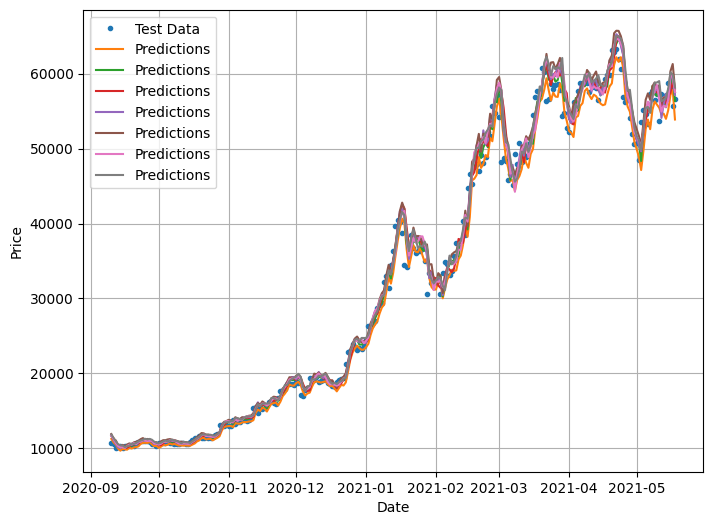

In [78]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (8,6))
plot_time_series(timesteps= X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):], values= model_3_preds, start= offset, format= '-', labels= 'Predictions')

When we try to plot our multi-horizon predicts, we get a funky looking plot.

Again, we can fix this by aggregating our model's predictions.

> 🔑 **Note:** Aggregating the predictions (e.g. reducing a 7-day horizon to one value such as the mean) loses information from the original prediction. As in, the model predictions were trained to be made for 7-days but by reducing them to one, we gain the ability to plot them visually but we lose the extra information contained across multiple days.

In [79]:
model_3_preds[0], model_3_preds[0].shape

(<tf.Tensor: shape=(7,), dtype=float32, numpy=
 array([9118.206, 9493.772, 9400.561, 9588.391, 9614.586, 9704.024,
        9739.886], dtype=float32)>,
 TensorShape([7]))

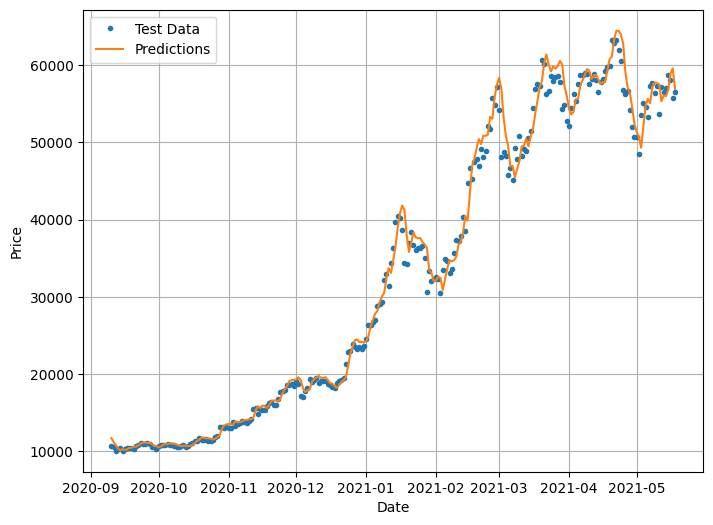

In [80]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (8,6))
plot_time_series(timesteps= X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):],
                 values= tf.reduce_mean(model_3_preds, axis= 1),
                 start= offset, format= '-', labels= 'Predictions')

## Which of our models is performing best so far?

So far, we've trained 3 models which use the same architecture but use different data inputs.

Let's compare them with the naïve model to see which model is performing the best so far.

<Axes: >

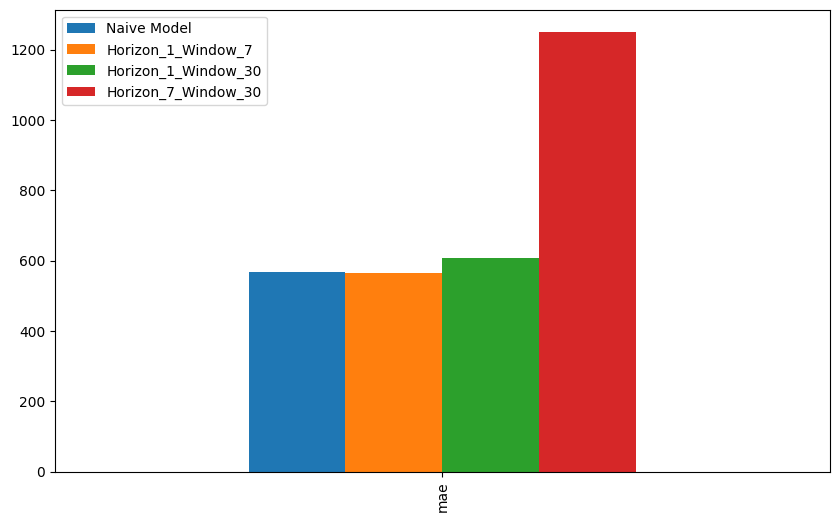

In [81]:
pd.DataFrame({'Naive Model': naive_results['mae'],
             'Horizon_1_Window_7': model_1_results['mae'],
             'Horizon_1_Window_30': model_2_results['mae'],
             'Horizon_7_Window_30': model_3_results['mae']},
             index= ['mae']).plot(kind= 'bar', figsize= (10,6))

Woah, our naïve model is performing best (it's very hard to beat a naïve model in open systems) but the dense model with a horizon of 1 and a window size of 7 looks to be performing cloest.

Because of this, let's use `HORIZON=1` and `WINDOW_SIZE=7` for our next series of modelling experiments (in other words, we'll use the previous week of Bitcoin prices to try and predict the next day).

> 🔑 **Note:** You might be wondering, why are the naïve results so good? One of the reasons could be due the presence of **autocorrelation** in the data. If a time series has **autocorrelation** it means the value at `t+1` (the next timestep) is typically close to the value at `t` (the current timestep). In other words, today's value is probably pretty close to yesterday's value. Of course, this isn't always the case but when it is, a naïve model will often get fairly good results.

> 📖 **Resource:** For more on how autocorrelation influences a model's predictions, see the article [*How (not) to use Machine Learning for time series forecasting: Avoiding the pitfalls*](https://towardsdatascience.com/how-not-to-use-machine-learning-for-time-series-forecasting-avoiding-the-pitfalls-19f9d7adf424) by Vegard Flovik

## Model 4: Conv1D

This time, we'll be using a Conv1D model. Because as we saw in the sequence modelling notebook, Conv1D models can be used for seq2seq (sequence to sequence) problems.

In our case, the input sequence is the previous 7 days of Bitcoin price data and the output is the next day (in seq2seq terms this is called a many to one problem).

![bitcoin prediction in seq2seq terms](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-bitcoin-forecast-in-seq2seq-terms.png)
*Framing Bitcoin forecasting in seq2seq (sequence to sequence) terms. Using a window size of 7 and a horizon of one results in a many to one problem. Using a window size of >1 and a horizon of >1 results in a many to many problem. The diagram comes from Andrei Karpathy's [The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)*.

Before we build a Conv1D model, let's recreate our datasets.

In [82]:
HORIZON = 1 # predict next day
WINDOW_SIZE = 7 # use previous week worth of data

In [83]:
# Creating Windowed Data:
full_windows, full_labels = make_windows(prices, window_size= WINDOW_SIZE, horizon= HORIZON)
full_windows.shape, full_labels.shape

((2780, 7), (2780, 1))

In [84]:
# Creating Train Test Split:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows= full_windows,
                                                                               labels= full_labels)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((2224, 7), (556, 7), (2224, 1), (556, 1))

since we're going to be using [Conv1D layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv1D), we need to make sure our input shapes are correct.

The Conv1D layer in TensorFlow takes an input of: `(batch_size, timesteps, input_dim)`.

In our case, the `batch_size` (by default this is 32 but we can change it) is handled for us but the other values will be:
* `timesteps = WINDOW_SIZE` - the `timesteps` is also often referred to as `features`, our features are the previous `WINDOW_SIZE` values of Bitcoin 
* `input_dim = HORIZON` - our model views `WINDOW_SIZE` (one week) worth of data at a time to predict `HORIZON` (one day)

Right now, our data has the `timesteps` dimension ready but we'll have to adjust it to have the `input_dim` dimension. 

In [85]:
# Check data sample shapes
train_windows[0].shape # returns (WINDOW_SIZE, )

(7,)

To fix this, we could adjust the shape of all of our `train_windows` or we could use a [`tf.keras.layers.Lamdba`](https://keras.io/api/layers/core_layers/lambda/) (called a Lambda layer) to do this for us in our model.

The Lambda layer wraps a function into a layer which can be used with a model.

Let's try it out.

In [86]:
# Before we pass our data to the Conv1D layer, we have to reshape it in order to make sure it works
x = tf.constant(train_windows[0])
expand_dims_layer = Lambda(lambda x: tf.expand_dims(x, axis= 1)) # add an extra dimension for timesteps
print(f'Original shape: {x.shape}') # (WINDOW_SIZE)
print(f'Expanded shape: {expand_dims_layer(x).shape}') # (WINDOW_SIZE, input_dim) 
print(f'Original values with expanded shape:\n {expand_dims_layer(x)}')

Original shape: (7,)
Expanded shape: (7, 1)
Original values with expanded shape:
 [[123.65499]
 [125.455  ]
 [108.58483]
 [118.67466]
 [121.33866]
 [120.65533]
 [121.795  ]]


Now we've got a Lambda layer, let's build, compile, fit and evaluate a Conv1D model on our data.

> 🔑 **Note:** If you run the model below without the Lambda layer, you'll get an input shape error (one of the most common errors when building neural networks).

In [87]:
# Creating The Model:

tf.random.set_seed(42)

model_4 = Sequential(name= 'Model_4_Conv1D')
# resize the inputs to adjust for window size / Conv1D 3D input requirements
model_4.add(Lambda(lambda x: tf.expand_dims(x, axis= 1)))
model_4.add(Conv1D(filters= 128, 
                  kernel_size= 5,
                  padding= 'causal',
                  activation= 'relu'))
model_4.add(Dense(units= HORIZON))

# Compiling The Model:
model_4.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_4_history = model_4.fit(x= train_windows,
                             y= train_labels,
                             validation_data= (test_windows, test_labels),
                             epochs= 100,
                             batch_size= 128,
                             callbacks= [create_model_checkpoint(model_name= model_4.name)])

Epoch 1/100
18/18 [==============================] - 1s 21ms/step - loss: 1763.3623 - mae: 1763.3623 - val_loss: 977.1376 - val_mae: 977.1376
Epoch 2/100
18/18 [==============================] - 0s 6ms/step - loss: 326.0587 - mae: 326.0587 - val_loss: 1700.1448 - val_mae: 1700.1448
Epoch 3/100
18/18 [==============================] - 0s 6ms/step - loss: 214.0841 - mae: 214.0841 - val_loss: 1028.3942 - val_mae: 1028.3942
Epoch 4/100
18/18 [==============================] - 0s 7ms/step - loss: 173.2570 - mae: 173.2570 - val_loss: 913.6740 - val_mae: 913.6740
Epoch 5/100
18/18 [==============================] - 0s 6ms/step - loss: 165.5135 - mae: 165.5135 - val_loss: 923.0079 - val_mae: 923.0079
Epoch 6/100
18/18 [==============================] - 0s 8ms/step - loss: 161.3017 - mae: 161.3017 - val_loss: 899.2137 - val_mae: 899.2137
Epoch 7/100
18/18 [==============================] - 0s 7ms/step - loss: 157.8612 - mae: 157.8612 - val_loss: 884.4711 - val_mae: 884.4711
Epoch 8/100
18/18 [=

In [88]:
# Evaluating The Model:
model_4.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 632.4524 - mae: 632.4524


[632.452392578125, 632.452392578125]

In [89]:
# Load in saved best performing model_4 and evaluate on test data:
model_4 = tf.keras.models.load_model('time_series_model_experiments/Model_4_Conv1D.keras',
                                    safe_mode= False)
model_4.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 2ms/step - loss: 570.5266 - mae: 570.5266


[570.526611328125, 570.526611328125]

In [90]:
# Making Predictions:
model_4_preds = make_preds(model_4, test_windows)
model_4_preds[:10]

18/18 [==============================] - 0s 2ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8877.596, 8771.434, 9009.057, 8786.442, 8738.094, 8749.721,
       8677.244, 8514.45 , 8471.236, 8514.223], dtype=float32)>

In [91]:
# Calculating Metrics for model_4:
model_4_results = evaluate_preds(y_true= tf.squeeze(test_labels),
                                y_pred= model_4_preds)
model_4_results

{'mae': 570.52655,
 'mse': 1177741.2,
 'rmse': 1085.2379,
 'mape': 2.5554376,
 'mase': 1.0022571}

## Model 5: RNN (LSTM)

> 📖 **Resource:** For more on the different types of recurrent neural networks you can use for sequence problems, see the [Recurrent Neural Networks section of notebook 08](https://dev.mrdbourke.com/tensorflow-deep-learning/08_introduction_to_nlp_in_tensorflow/#recurrent-neural-networks-rnns).

Let's reuse the same data we used for the Conv1D model, except this time we'll create an [LSTM-cell](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM) powered RNN to model our Bitcoin data. 

Once again, one of the most important steps for the LSTM model will be getting our data into the right shape.

The [`tf.keras.layers.LSTM()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM) layer takes a tensor with `[batch, timesteps, feature]` dimensions.

As mentioned earlier, the `batch` dimension gets taken care of for us but our data is currently only has the `feature` dimension (`WINDOW_SIZE`).

To fix this, just like we did with the `Conv1D` model, we can use a `tf.keras.layers.Lambda()` layer to adjust the shape of our input tensors to the LSTM layer.

In [92]:
# Creating The Model:
tf.random.set_seed(42)

inputs = Input(shape= (WINDOW_SIZE))

# Expand input dimension to be compatible with LSTM
x = Lambda(lambda x : tf.expand_dims(x, axis= 1))(inputs)
x = LSTM(units= 128, activation= 'relu')(x)
output = Dense(units= HORIZON)(x)

model_5 = Model(inputs, output, name= 'Model_5_LSTM')

# Compiling The Model:
model_5.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_5_history = model_5.fit(x= train_windows,
                             y= train_labels,
                             validation_data= (test_windows, test_labels),
                             epochs= 100,
                             batch_size= 128,
                             callbacks= [create_model_checkpoint(model_name= model_5.name)])

Epoch 1/100
18/18 [==============================] - 1s 15ms/step - loss: 2188.2061 - mae: 2188.2061 - val_loss: 5511.4722 - val_mae: 5511.4722
Epoch 2/100
18/18 [==============================] - 0s 8ms/step - loss: 361.8003 - mae: 361.8003 - val_loss: 1567.0127 - val_mae: 1567.0127
Epoch 3/100
18/18 [==============================] - 0s 7ms/step - loss: 194.0744 - mae: 194.0744 - val_loss: 938.9938 - val_mae: 938.9938
Epoch 4/100
18/18 [==============================] - 0s 7ms/step - loss: 169.2956 - mae: 169.2956 - val_loss: 929.4230 - val_mae: 929.4230
Epoch 5/100
18/18 [==============================] - 0s 9ms/step - loss: 163.1140 - mae: 163.1140 - val_loss: 861.9750 - val_mae: 861.9750
Epoch 6/100
18/18 [==============================] - 0s 7ms/step - loss: 168.3865 - mae: 168.3865 - val_loss: 928.6792 - val_mae: 928.6792
Epoch 7/100
18/18 [==============================] - 0s 8ms/step - loss: 166.3727 - mae: 166.3727 - val_loss: 892.5803 - val_mae: 892.5803
Epoch 8/100
18/18 [=

In [93]:
# Evaluating The Model:
model_5.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 3ms/step - loss: 592.1241 - mae: 592.1241


[592.1240844726562, 592.1240844726562]

In [94]:
# Load in saved best performing model_5 and evaluate on test data:
model_5 = tf.keras.models.load_model('time_series_model_experiments/Model_5_LSTM.keras',
                                    safe_mode= False)
model_5.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 3ms/step - loss: 583.8640 - mae: 583.8640


[583.864013671875, 583.864013671875]

In [95]:
# Making Predictions:
model_5_preds = make_preds(model_5, test_windows)
model_5_preds[:10]

18/18 [==============================] - 0s 1ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8938.129, 8809.677, 9013.708, 8788.142, 8729.144, 8778.101,
       8710.335, 8521.731, 8498.012, 8528.655], dtype=float32)>

In [96]:
# Calculating Metrics for model_4:
model_5_results = evaluate_preds(y_true= tf.squeeze(test_labels),
                                y_pred= model_5_preds)
model_5_results

{'mae': 583.864,
 'mse': 1224237.2,
 'rmse': 1106.4525,
 'mape': 2.6166477,
 'mase': 1.0256873}

## Make a multivariate time series 

So far all of our models have barely kept up with the naïve forecast.

And so far all of them have been trained on a single variable (also called univariate time series): the historical price of Bitcoin.

If predicting the price of Bitcoin using the price of Bitcoin hasn't worked out very well, maybe giving our model more information may help.

More information is a vague term because we could actually feed almost anything to our model(s) and they would still try to find patterns. 

For example, we could use the historical price of Bitcoin as well as anyone with the name [Daniel Bourke Tweeted](https://twitter.com/mrdbourke) on that day to predict the future price of Bitcoin.

But would this help?

Porbably not.

What would be better is if we passed our model something related to Bitcoin (again, this is quite vauge, since in an open system like a market, you could argue everything is related).

This will be different for almost every time series you work on but in our case, we could try to see if the [Bitcoin block reward size](https://www.investopedia.com/terms/b/block-reward.asp) adds any predictive power to our model(s).

What is the Bitcoin block reward size?

The Bitcoin block reward size is the number of Bitcoin someone receives from mining a Bitcoin block.

At its inception, the Bitcoin block reward size was 50.

But every four years or so, the Bitcoin block reward halves.

For example, the block reward size went from 50 (starting January 2009) to 25 on November 28 2012.

Let's encode this information into our time series data and see if it helps a model's performance.

> 🔑 **Note:** Adding an extra feature to our dataset such as the Bitcoin block reward size will take our data from **univariate** (only the historical price of Bitcoin) to **multivariate** (the price of Bitcoin as well as the block reward size).

In [97]:
# Let's make a multivariate time series:
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


Alright, time to add another feature column, the block reward size.

First, we'll need to create variables for the different block reward sizes as well as the dates they came into play.

The following block rewards and dates were sourced from [cmcmarkets.com](https://www.cmcmarkets.com/en/learn-cryptocurrencies/bitcoin-halving).

| Block Reward | Start Date |
| ----- | ----- |
| 50 | 3 January 2009 (2009-01-03) |
| 25 | 28 November 2012 |
| 12.5 | 9 July 2016 |
| 6.25 | 11 May 2020 |
| 3.125 | TBA (expected 2024) |
| 1.5625 | TBA (expected 2028) | 

> 🔑 **Note:** Since our Bitcoin historical data starts from 01 October 2013, none of the timesteps in our multivariate time series will have a block reward of 50.

In [98]:
# Block Reward Values:
block_reward_1 = 50 # 3 January 2009 (2009-01-03) - this block reward isn't in our dataset (it starts from 01 October 2013)
block_reward_2 = 25 # 28 November 2012
block_reward_3 = 12.5 # 9 July 2016
block_reward_4 = 6.25 # 11 May 2020

# Block Reward Dates:
block_reward_2_datetime = np.datetime64('2012-11-28')
block_reward_3_datetime = np.datetime64('2016-07-09')
block_reward_4_datetime = np.datetime64('2020-05-11')

We're going to get the days (indexes) for different block reward values. 

This is important because if we're going to use multiple variables for our time series, they have to the same frequency as our original variable. For example, if our Bitcoin prices are daily, we need the block reward values to be daily as well.

> 🔑 **Note:** For using multiple variables, make sure they're the same frequency as each other. If your variables aren't at the same frequency (e.g. Bitcoin prices are daily but block rewards are weekly), you may need to transform them in a way that they can be used with your model.

In [99]:
# Get date indexes for when to add in different block dates:
block_reward_2_days = (block_reward_3_datetime - bitcoin_prices.index[0]).days
block_reward_3_days = (block_reward_4_datetime - bitcoin_prices.index[0]).days

block_reward_2_days, block_reward_3_days

(1012, 2414)

In [100]:
# Add block_reward column
bitcoin_prices_block = bitcoin_prices.copy()
bitcoin_prices_block['Block_Reward'] = None

bitcoin_prices_block.head()

,Price,Block_Reward
Date,,
2013-10-01,123.65499,None
2013-10-02,125.45500,None
2013-10-03,108.58483,None
2013-10-04,118.67466,None
2013-10-05,121.33866,None


In [101]:
# Set values of block_reward column (it's the last column hence -1 indexing on iloc):
bitcoin_prices_block.iloc[:block_reward_2_days, -1] = block_reward_2
bitcoin_prices_block.iloc[block_reward_2_days : block_reward_3_days, -1] = block_reward_3
bitcoin_prices_block.iloc[block_reward_3_days:, -1] = block_reward_4

In [102]:
bitcoin_prices_block.head()

,Price,Block_Reward
Date,,
2013-10-01,123.65499,25
2013-10-02,125.45500,25
2013-10-03,108.58483,25
2013-10-04,118.67466,25
2013-10-05,121.33866,25


In [103]:
bitcoin_prices_block.tail()

,Price,Block_Reward
Date,,
2021-05-14,49764.132082,6.25
2021-05-15,50032.693137,6.25
2021-05-16,47885.625255,6.25
2021-05-17,45604.615754,6.25
2021-05-18,43144.471291,6.25


In [104]:
bitcoin_prices_block['Block_Reward'].value_counts()

Block_Reward
12.5    1402
25      1012
6.25     373
Name: count, dtype: int64

<Axes: xlabel='Date'>

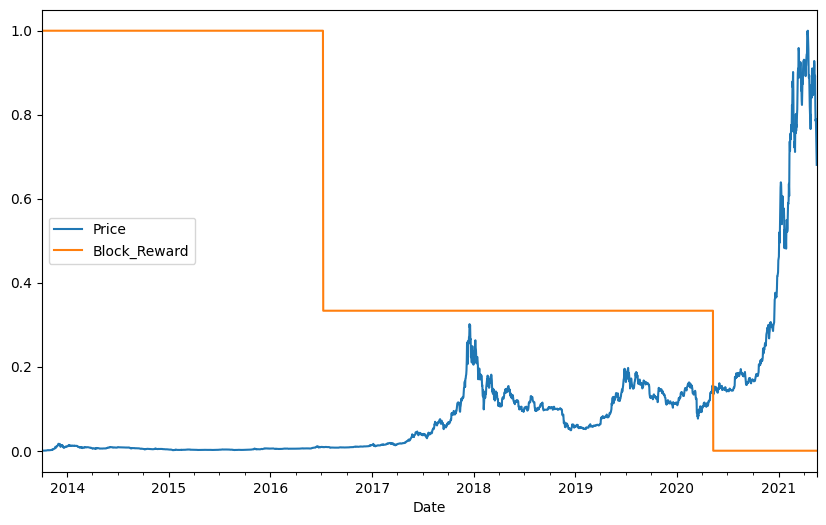

In [105]:
# Plotting Prices and Block Reward Over Time By Adjusting Scales of Data:
from sklearn.preprocessing import minmax_scale

scaled_bitcoin_prices_block_df = pd.DataFrame(minmax_scale(bitcoin_prices_block[['Price', 'Block_Reward']]),
                                             columns= bitcoin_prices_block.columns,
                                             index= bitcoin_prices_block.index)
scaled_bitcoin_prices_block_df.plot(figsize= (10,6))

## Making a windowed dataset with pandas

Previously, we used some custom made functions to window our **univariate** time series.

However, since we've just added another variable to our dataset, these functions won't work.

Not to worry though. Since our data is in a pandas DataFrame, we can leverage the [`pandas.DataFrame.shift()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.shift.html) method to create a windowed **multivariate** time series.

The `shift()` method offsets an index by a specified number of periods.

In [106]:
# Setup dataset hyperparameters
HORIZON = 1
WINDOW_SIZE = 7

In [107]:
# Make a copy of the Bitcoin historical data with block reward feature:
bitcoin_prices_windowed = bitcoin_prices_block.copy()

# Add Windowed Columns:
for i in range(WINDOW_SIZE):
    bitcoin_prices_windowed[f'Price+{i+1}'] = bitcoin_prices_windowed['Price'].shift(periods= i+1)

bitcoin_prices_windowed.head(10)

,Price,Block_Reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2013-10-01,123.65499,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,25,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,25,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,25,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,25,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN
2013-10-06,120.65533,25,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN
2013-10-07,121.79500,25,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN
2013-10-08,123.03300,25,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,25,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500


Now that we've got a windowed dataset, let's separate features (`X`) from labels (`y`).

Remember in our windowed dataset, we're trying to use the previous `WINDOW_SIZE` steps to predict `HORIZON` steps.

```
Window for a week (7) to predict a horizon of 1 (multivariate time series)
WINDOW_SIZE & block_reward -> HORIZON

[0, 1, 2, 3, 4, 5, 6, block_reward] -> [7]
[1, 2, 3, 4, 5, 6, 7, block_reward] -> [8]
[2, 3, 4, 5, 6, 7, 8, block_reward] -> [9]
```

We'll also remove the `NaN` values using pandas [`dropna()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html) method, this equivalent to starting our windowing function at `sample 0 (the first sample) + WINDOW_SIZE`.

In [108]:
# Let's create X & y, remove the NaN's and convert to float32 to prevent TensorFlow errors:
X = bitcoin_prices_windowed.dropna().drop('Price', axis= 1).astype(np.float32)
y = bitcoin_prices_windowed.dropna()['Price'].astype(np.float32)

In [109]:
X.head()

,Block_Reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2013-10-08,25.0,121.794998,120.655327,121.338661,118.674660,108.584831,125.455002,123.654991
2013-10-09,25.0,123.032997,121.794998,120.655327,121.338661,118.674660,108.584831,125.455002
2013-10-10,25.0,124.049004,123.032997,121.794998,120.655327,121.338661,118.674660,108.584831
2013-10-11,25.0,125.961159,124.049004,123.032997,121.794998,120.655327,121.338661,118.674660
2013-10-12,25.0,125.279663,125.961159,124.049004,123.032997,121.794998,120.655327,121.338661


In [110]:
y.head()

Date
2013-10-08    123.032997
2013-10-09    124.049004
2013-10-10    125.961159
2013-10-11    125.279663
2013-10-12    125.927498
Name: Price, dtype: float32

In [111]:
# Making Training and Test Data Series:
split_size = int(0.8 * len(X))
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2224, 8), (556, 8), (2224,), (556,))

## Model 6: Dense (multivariate time series)

To keep things simple, let's the `model_1` architecture and use it to train and make predictions on our multivariate time series data.

By replicating the `model_1` architecture we'll be able to see whether or not adding the block reward feature improves or detracts from model performance.

In [112]:
# Creating The Model:

tf.random.set_seed(42)

model_6 = Sequential(name= 'Model_6_MultiVariate')
model_6.add(Dense(units= 128, activation= 'relu'))
model_6.add(Dense(units= HORIZON))

# Compiling The Model:
model_6.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_6_history = model_6.fit(x= X_train,
                             y= y_train,
                             validation_data= (X_test, y_test),
                             epochs= 100,
                             batch_size= 128,
                             callbacks= [create_model_checkpoint(model_name= model_6.name)])

Epoch 1/100
18/18 [==============================] - 1s 13ms/step - loss: 1810.4160 - mae: 1810.4160 - val_loss: 1160.9734 - val_mae: 1160.9734
Epoch 2/100
18/18 [==============================] - 0s 5ms/step - loss: 391.3630 - mae: 391.3630 - val_loss: 1796.6752 - val_mae: 1796.6752
Epoch 3/100
18/18 [==============================] - 0s 4ms/step - loss: 244.8587 - mae: 244.8587 - val_loss: 1167.0723 - val_mae: 1167.0723
Epoch 4/100
18/18 [==============================] - 0s 5ms/step - loss: 205.6102 - mae: 205.6102 - val_loss: 1114.5164 - val_mae: 1114.5164
Epoch 5/100
18/18 [==============================] - 0s 6ms/step - loss: 198.3643 - mae: 198.3643 - val_loss: 1112.2493 - val_mae: 1112.2493
Epoch 6/100
18/18 [==============================] - 0s 7ms/step - loss: 193.9680 - mae: 193.9680 - val_loss: 1081.8138 - val_mae: 1081.8138
Epoch 7/100
18/18 [==============================] - 0s 6ms/step - loss: 193.1664 - mae: 193.1664 - val_loss: 1062.3325 - val_mae: 1062.3325
Epoch 8/10

In [113]:
# Evaluating The Model:
model_6.evaluate(X_test, y_test)

18/18 [==============================] - 0s 3ms/step - loss: 634.4236 - mae: 634.4236


[634.4236450195312, 634.4236450195312]

In [114]:
# Load in saved best performing model_6 and evaluate on test data:
model_6 = tf.keras.models.load_model('time_series_model_experiments/Model_6_MultiVariate.keras')
model_6.evaluate(X_test, y_test)

18/18 [==============================] - 0s 2ms/step - loss: 563.1447 - mae: 563.1447


[563.1446533203125, 563.1446533203125]

In [115]:
# Making Predictions:
model_6_preds = make_preds(model_6, X_test)
model_6_preds[:10]

18/18 [==============================] - 0s 1ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8865.276 , 8800.139 , 9040.2705, 8810.905 , 8773.86  , 8732.763 ,
       8700.8   , 8557.142 , 8468.995 , 8543.751 ], dtype=float32)>

In [116]:
# Calculating Metrics for Model 6:
model_6_results = evaluate_preds(y_true= y_test,
                                y_pred= model_6_preds)
model_6_results

{'mae': 563.1446,
 'mse': 1150737.8,
 'rmse': 1072.7244,
 'mape': 2.527949,
 'mase': 0.98928905}

## Model 7: N-BEATS algorithm

So far we've tried a bunch of smaller models, models with only a couple of layers.

But one of the best ways to improve a model's performance is to increase the number of layers in it.

That's exactly what the [N-BEATS (Neural Basis Expansion Analysis for Interpretable Time Series Forecasting) algorithm](https://arxiv.org/pdf/1905.10437.pdf) does.

The N-BEATS algorithm focuses on univariate time series problems and achieved state-of-the-art performance in the winner of the [M4 competition](https://www.sciencedirect.com/science/article/pii/S0169207019301128) (a forecasting competition).

For our next modelling experiment we're going to be replicating the **generic architecture** of the N-BEATS algorithm (see [section 3.3 of the N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf)).

We're not going to go through all of the details in the paper, instead we're going to focus on:
1. Replicating the model architecture in [Figure 1 of the N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf) 

![figure 1 from N-BBEATS paper, the algorithm we're going to build](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-figure-1-nbeats-paper-annotated.png)
*N-BEATS algorithm we're going to replicate with TensorFlow with window (input) and horizon (output) annotations.*

2. Using the same hyperparameters as the paper which can be found in [Appendix D of the N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf)

Doing this will give us an opportunity to practice:
* Creating a custom layer for the `NBeatsBlock` by subclassing [`tf.keras.layers.Layer`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer)
  * Creating a custom layer is helpful for when TensorFlow doesn't already have an existing implementation of a layer or if you'd like to make a layer configuration repeat a number of times (e.g. like a stack of N-BEATS blocks)
* Implementing a custom architecture using the Functional API 
* Finding a paper related to our problem and seeing how it goes 

> 🔑 **Note:** As you'll see in the paper, the authors state “N-BEATS is implemented and trained in TensorFlow”, that's what we'll be doing too!

### Building and testing an N-BEATS block layer

Let's start by building an N-BEATS block layer.

In [117]:
# Creating NBeatsBlock custom layer:

class NBeatsBlock(tf.keras.layers.Layer):

    def __init__(self, # the constructor takes all the hyperparameters for the layer
                input_size: int,
                theta_size: int,
                horizon: int,
                n_neurons: int,
                n_layers: int,
                **kwargs): # the **kwargs argument takes care of all of the arguments for the parent class (input_shape, trainable, name)

        super().__init__(**kwargs)
        self.input_size = input_size
        self.theta_size = theta_size
        self.horizon = horizon
        self.n_neurons = n_neurons
        self.n_layers = n_layers

        # Block contains stack of 4 fully connected layers each has ReLU activation:
        self.hidden = [tf.keras.layers.Dense(n_neurons, activation= 'relu') for _ in range(n_layers)]

        # Output of block is a theta layer with linear activation:
        self.theta_layer = tf.keras.layers.Dense(theta_size, activation= 'linear', name= 'theta')

    def call(self, inputs): # the call method is what runs when the layer is called
        
        x = inputs

        for layer in self.hidden: # pass inputs through each hidden layer 
            x = layer(x)

        theta = self.theta_layer(x)

        # Output the backcast and forecast from theta:
        backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
        return backcast, forecast

Setting up the `NBeatsBlock` custom layer we see: 
* The class inherits from `tf.keras.layers.Layer` (this gives it all of the methods assosciated with `tf.keras.layers.Layer`)
* The constructor (`def __init__(...)`) takes all of the layer hyperparameters as well as the `**kwargs` argument
  * The `**kwargs` argument takes care of all of the hyperparameters which aren't mentioned in the constructor such as, `input_shape`, `trainable` and `name`
* In the constructor, the block architecture layers are created:
  * The hidden layers are created as a stack of fully connected with `n_nuerons` hidden units layers with ReLU activation
  * The theta layer uses `theta_size` hidden units as well as linear activation
* The `call()` method is what is run when the layer is called:
  * It first passes the inputs (the historical Bitcoin data) through each of the hidden layers (a stack of fully connected layers with ReLU activation)
  * After the inputs have been through each of the fully connected layers, they get passed through the theta layer where the backcast (backwards predictions, shape: `input_size`) and forecast (forward predictions, shape: `horizon`) are returned

![code mapping to image of N-BEATS basic block](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-nbeats-basic-block-replication-with-tensorflow-layer-subclassing.png)
*Using TensorFlow layer subclassing to replicate the N-BEATS basic block. See section 3.1 of N-BEATS paper for details.*

Let's see our block replica in action by together by creating a toy version of `NBeatsBlock`.

> 📖  **Resource:** Much of the creation of the time series materials (the ones you're going through now), including replicating the N-BEATS algorithm were streamed live on Twitch. If you'd like to see replays of how the algorithm was replicated, check out the [*Time series research and TensorFlow course material creation playlist*](https://youtube.com/playlist?list=PL8IpyNZ21vUSCM7nRAuS-hW_E-sgwdmaI) on the Daniel Bourke arXiv YouTube channel.

In [118]:
# Set up dummy NBeatsBlock layer to represent inputs and outputs:
dummy_nbeats_block_layer = NBeatsBlock(input_size= WINDOW_SIZE,
                                      theta_size= WINDOW_SIZE + HORIZON, # backcast + forecast 
                                      horizon= HORIZON,
                                      n_neurons= 128,
                                      n_layers= 4)

In [119]:
# Create dummy inputs (have to be same size as input_size)
# input shape to the model has to reflect Dense layer input requirements (ndim=2)

dummy_inputs = tf.expand_dims(tf.range(WINDOW_SIZE) + 1, axis= 0) # input shape to the model has to reflect Dense layer input requirements (ndim=2)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [120]:
# Pass dummy inputs to dummy NBeatsBlock layer:
backcast, forecast = dummy_nbeats_block_layer(dummy_inputs)
print(f'Backcast: {tf.squeeze(backcast.numpy())}')
print(f'Forecast: {tf.squeeze(forecast.numpy())}')

Backcast: [-0.3050014   0.4400618  -0.14422128 -1.4049826   1.683728    0.7376592
 -0.08805919]
Forecast: -0.7877838611602783


### Preparing data for the N-BEATS algorithm using `tf.data`

We've got the basic building block for the N-BEATS architecture ready to go.

But before we use it to replicate the entire N-BEATS generic architecture, let's create some data.

This time, because we're going to be using a larger model architecture, to ensure our model training runs as fast as possible, we'll setup our datasets using the `tf.data` API.

And because the N-BEATS algorithm is focused on univariate time series, we'll start by making training and test windowed datasets of Bitcoin prices (just as we've done above).

In [121]:
HORIZON = 1 # how far to predict forward
WINDOW_SIZE = 7 # how far to lookback

In [122]:
# Create NBEATS data inputs (NBEATS works with univariate time series)
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


In [123]:
# Adding Windowed Columns:
bitcoin_prices_nbeats = bitcoin_prices.copy()
for i in range(WINDOW_SIZE):
    bitcoin_prices_nbeats[f'Price{i+1}'] = bitcoin_prices_nbeats['Price'].shift(periods= i+1)

bitcoin_prices_nbeats.head(10)

,Price,Price1,Price2,Price3,Price4,Price5,Price6,Price7
Date,,,,,,,,
2013-10-01,123.65499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN
2013-10-06,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN
2013-10-07,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN
2013-10-08,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500


In [124]:
# Making Features and labels:
X = bitcoin_prices_nbeats.dropna().drop('Price', axis= 1)
y = bitcoin_prices_nbeats.dropna()['Price']

In [125]:
X.shape, y.shape

((2780, 7), (2780,))

In [126]:
# Making Training and Test Data Sets:
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2224, 7), (2224,), (556, 7), (556,))

Now let's convert them into TensorFlow `tf.data.Dataset`'s to ensure they run as fast as possible whilst training.

We'll do this by:
1. Turning the arrays in tensor Datasets using [`tf.data.Dataset.from_tensor_slices()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices)
  * Note: `from_tensor_slices()` works best when your data fits in memory, for extremely large datasets, you'll want to look into using the [`TFRecord` format](https://www.tensorflow.org/tutorials/load_data/tfrecord)
2. Combine the labels and features tensors into a Dataset using [`tf.data.Dataset.zip()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#zip)
3. Batch and prefetch the Datasets using [`batch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch) and [`prefetch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch)
  * Batching and prefetching ensures the loading time from CPU (preparing data) to GPU (computing on data) is as small as possible 

> 📖 **Resource:** For more on building highly performant TensorFlow data pipelines, I'd recommend reading through the [*Better performance with the tf.data API*](https://www.tensorflow.org/guide/data_performance) guide.

In [127]:
# 1. Turn train and test arrays into tensor Datasets:
train_features_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(y_train)

test_features_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(y_test)

# 2. Combine features & labels:
train_dataset = tf.data.Dataset.zip((train_features_dataset, train_labels_dataset))
test_dataset = tf.data.Dataset.zip((test_features_dataset, test_labels_dataset))

# 3. Batch and prefetch for optimal performance
BATCH_SIZE = 1024
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset, test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

### Setting up hyperparameters for N-BEATS algorithm

We'll create variables for each of the hyperparameters we'll be using for our N-BEATS replica.

> 📖 **Resource:** The following hyperparameters are taken from Figure 1 and Table 18/Appendix D of the [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf).

![table 18 from N-BEATS paper](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-nbeats-table-18-hyperparameters.png)
*Table 18 from [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf) describing the hyperparameters used for the different variants of N-BEATS. We're using N-BEATS-G which stands for the generic version of N-BEATS.*

> 🔑 **Note:** If you see variables in a machine learning example in all caps, such as "`N_EPOCHS = 100`", these variables are often hyperparameters which are used through the example. You'll usually see them instantiated towards the start of an experiment and then used throughout.

In [128]:
# Values from N-BEATS paper Figure 1 and Table 18/Appendix D
N_EPOCHS = 5000 # called "Iterations" in Table 18
N_NEURONS = 512 # called "Width" in Table 18
N_LAYERS = 4
N_STACKS= 30
INPUT_SIZE = WINDOW_SIZE * HORIZON
THETA_SIZE = INPUT_SIZE + HORIZON

In [129]:
INPUT_SIZE, THETA_SIZE

(7, 8)

### Getting ready for residual connections

Now before we create the N-BEATS model, there are two layers to go through which play a large roll in the architecture.

They're what make N-BEATS **double residual stacking** (section 3.2 of the [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf)) possible:
* [`tf.keras.layers.subtract(inputs)`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/subtract) - subtracts list of input tensors from each other
* [`tf.keras.layers.add(inputs)`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/add) - adds list of input tensors to each other.

In [130]:
# Make Tensors:
tensor_1 = tf.range(10) + 10
tensor_2 = tf.range(10)

# Subtract:
subtracted = tf.keras.layers.subtract([tensor_1, tensor_2])

# Add:
added = tf.keras.layers.add([tensor_1, tensor_2])

print(f'Input tensors: {tensor_1.numpy()} & {tensor_2.numpy()}')
print(f'Subtracted: {subtracted.numpy()}')
print(f'Added: {added.numpy()}')

Input tensors: [10 11 12 13 14 15 16 17 18 19] & [0 1 2 3 4 5 6 7 8 9]
Subtracted: [10 10 10 10 10 10 10 10 10 10]
Added: [10 12 14 16 18 20 22 24 26 28]


Both of these layer functions are straight-forward, subtract or add together their inputs.

And as mentioned before, they're what powers N-BEATS double residual stacking.

The power of **residual stacking** or **residual connections** was revealed in [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) where the authors were able to build a deeper but less complex neural network (this is what introduced the popular [ResNet architecture](https://en.wikipedia.org/wiki/Residual_neural_network)) than previous attempts. 

This deeper neural network led to state of the art results on the ImageNet challenge in 2015 and different versions of residual connections have been present in deep learning ever since.

> What is a residual connection?

A **residual connection** (also called skip connections) involves a deeper neural network layer receiving the outputs as well as the inputs of a shallower neural network layer.

In the case of N-BEATS, the architecture uses residual connections which:
* Subtract the backcast outputs from a previous block from the backcast inputs to the current block
* Add the forecast outputs from all blocks together in a stack 

![N-BEATS architecture double residual stacking](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-nbeats-architecture-double-residual-stacking.png)
*Annotated version of Figure 1 from the N-BEATS paper highlighting the double residual stacking (section 3.2) of the architecture. Backcast residuals of each block are subtracted from each other and used as the input to the next block where as the forecasts of each block are added together to become the stack forecast.*

> What are the benefits of residual connections?

In practice, residual connections have been beneficial for training deeper models (N-BEATS reaches ~150 layers, also see "These approaches provide clear advantages in improving the trainability of deep architectures" in section 3.2 of the [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf)).  

It's thought that they help avoid the problem of [vanishing gradients](https://en.wikipedia.org/wiki/Vanishing_gradient_problem) (patterns learned by a neural network not being passed through to deeper layers).

### Building, compiling and fitting the N-BEATS algorithm 

We've finally got all of the pieces of the puzzle ready for building and training the N-BEATS algorithm.

We'll do so by going through the following:

1. Setup an instance of the N-BEATS block layer using `NBeatsBlock` (this'll be the initial block used for the network, the rest will be created as part of stacks)
2. Create an input layer for the N-BEATS stack (we'll be using the [Keras Functional API](https://www.tensorflow.org/guide/keras/functional) for this)
3. Make the initial backcast and forecasts for the model with the layer created in (1)
4. Use a for loop to create stacks of block layers
5. Use the NBeatsBlock class within the for loop created in (4) to create blocks which return backcasts and block-level forecasts
6. Create the double residual stacking using subtract and add layers
7. Put the model inputs and outputs together using [`tf.keras.Model()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model)
8. Compile the model with MAE loss (the paper uses multiple losses but we'll use MAE to keep it inline with our other models) and Adam optimizer with default settings as per section 5.2 of [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf))
9. Fit the N-BEATS model for 5000 epochs and since it's fitting for so many epochs, we'll use a couple of callbacks:
  * [`tf.keras.callbacks.EarlyStopping()`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) - stop the model from training if it doesn't improve validation loss for 200 epochs and restore the best performing weights using `restore_best_weights=True` (this'll prevent the model from training for loooongggggg period of time without improvement)
  * [`tf.keras.callbacks.ReduceLROnPlateau()`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ReduceLROnPlateau) - if the model's validation loss doesn't improve for 100 epochs, reduce the learning rate by 10x to try and help it make incremental improvements (the smaller the learning rate, the smaller updates a model tries to make)

In [131]:
# Creating The Model:

tf.random.set_seed(42)

# 1. Setup N_BEATS Block Layer:
nbeats_block_layer = NBeatsBlock(input_size= INPUT_SIZE,
                                theta_size= THETA_SIZE,
                                horizon= HORIZON,
                                n_neurons= N_NEURONS,
                                n_layers= N_LAYERS,
                                name= 'Initial_Block')

# 2. Create Input to Stacks:
stack_input = Input(shape= (INPUT_SIZE), name= 'Stack_Input')

# 3. Create Initial BackCast and Forecats Input:
residuals, forecast = nbeats_block_layer(stack_input)

# 4. Create Stacks of Blocks:
for i, _ in enumerate(range(N_STACKS - 1)): # first stack is already creted in (3)

    # 5. Use the NBeatsBlock to calculate the backcast as well as block forecast:
    backcast, block_forecast = NBeatsBlock(input_size= INPUT_SIZE,
                                          theta_size= THETA_SIZE,
                                          horizon= HORIZON,
                                          n_neurons= N_NEURONS,
                                          n_layers= N_LAYERS,
                                          name= f'NBeatsBlock_{i}')(residuals)
    
    # 6. Create the double residual stacking:
    residuals = subtract([residuals, backcast], name= f'subtract_{i}')
    forecast = add([forecast, block_forecast], name=f'add_{i}')

# 7. Put the Stack Model Together:
model_7 = Model(inputs= stack_input,
               outputs= forecast,
               name= 'Model_7_nBEATS')

# 8. Compile Model With MAE Loss and Adam Optimizer:
model_7.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae', 'mse'])

# 9. Fit the Model with EarlyStopping and ReduceLROnPlateau Callbacks:
model_7_history = model_7.fit(x= train_dataset,
                             epochs= N_EPOCHS,
                             validation_data= test_dataset,
                             verbose= 0, # prevent large amounts of training outputs as N_EPOCHS= 5000
                             callbacks= [EarlyStopping(monitor= 'val_loss',
                                                      patience= 200,
                                                      restore_best_weights= True),
                                        ReduceLROnPlateau(monitor= 'val_loss',
                                                         patience= 100,
                                                         verbose= 1)])


Epoch 868: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 968: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


In [132]:
# Evaluate N-BEATS model on the test dataset:
model_7.evaluate(test_dataset)

1/1 [==============================] - 0s 18ms/step - loss: 578.5945 - mae: 578.5945 - mse: 1198131.6250


[578.594482421875, 578.594482421875, 1198131.625]

In [133]:
# Making predictions with N-BEATS model:
model_7_preds = make_preds(model_7, test_dataset)
model_7_preds[:10]

1/1 [==============================] - 1s 656ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8878.793, 8780.154, 9015.754, 8788.158, 8714.017, 8740.165,
       8682.521, 8517.804, 8464.242, 8516.924], dtype=float32)>

In [134]:
# Calculating Metrics for model_7:
model_7_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_7_preds)
model_7_results

{'mae': 578.5945,
 'mse': 1198131.6,
 'rmse': 1094.5919,
 'mape': 2.6286623,
 'mase': 1.0164303}

Even with all of those special layers and hand-crafted network, it looks like the N-BEATS model doesn't perform as well as `model_1` or the original naive forecast.

This goes to show the power of smaller networks as well as the fact not all larger models are better suited for a certain type of data.

In [135]:
# Plotting Model:
import pydot
import graphviz
from tensorflow.keras.utils import plot_model

plot_model(model= model_7,
          to_file= 'nBEATS_Model_Time_Series.png',
          show_shapes= True,
          show_layer_names= True,
          show_dtype= True,
          show_layer_activations= True,
          dpi= 250)

It looks similar to the model shown in Figure 1 of the N-BEATS paper. 

![N-BEATS replica model compared with actual N-BEATS architecture](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-nbeats-stack-model-vs-nbeats-architecture.png)
*Comparison of `model_7` (N-BEATS replica model make with Keras Functional API) versus actual N-BEATS architecture diagram.*

Looks like our Functional API usage did the trick! 

> 🔑 **Note:** Our N-BEATS model replicates the N-BEATS **generic architecture**, the training setups are largely the same, except for the N-BEATS paper used an ensemble of models to make predictions (multiple different loss functions and multiple different lookback windows), see Table 18 of the [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf) for more.

## Model 8: Creating an ensemble (stacking different models together)

After all that effort, the N-BEATS algorithm's performance was underwhelming.

Our next experiment is creating an [**ensemble** of models](https://en.wikipedia.org/wiki/Ensemble_learning).

An **ensemble** involves training and combining multiple different models on the same problem. Ensemble models are often the types of models you'll see winning data science competitions on websites like Kaggle.

![high level overview of ensemble model: combining many different models may result in better results than one single model](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-ensemble-model-example.png)
*Example of the power of ensembling. One Daniel model makes a decision with a smart level of 7 but when a Daniel model teams up with multiple different people, together (ensembled) they make a decision with a smart level of 10. The key here is combining the decision power of people with different backgrounds, if you combined multiple Daniel models, you'd end up with an average smart level of 7. Note: smart level is not an actual measurement of decision making, it is for demonstration purposes only.*

For example, in the N-BEATS paper, they trained an ensemble of models (180 in total, see [section 3.4](https://arxiv.org/pdf/1905.10437.pdf)) to achieve the results they did using a combination of:
  * Different loss functions (sMAPE, MASE and MAPE)
  * Different window sizes (2 x horizon, 3 x horizon, 4 x horizon...)

The benefit of ensembling models is you get the "decision of the crowd effect". Rather than relying on a single model's predictions, you can [take the average or median of many different models](https://en.wikipedia.org/wiki/Ensemble_forecasting).

The keyword being: different.

It wouldn't make sense to train the same model 10 times on the same data and then average the predictions.

Fortunately, due to their random initialization, even deep learning models with the same architecture can produce different results. 

What I mean by this is each time you create a deep learning model, it starts with random patterns (weights & biases) and then it adjusts these random patterns to better suit the dataset it's being trained on. 

However, the process it adjusts these patterns is often a form of guided randomness as well (the SGD optimizer stands for stochastic or random gradient descent).

To create our ensemble models we're going to be using a combination of: 
* Different loss functions (MAE, MSE, MAPE)
* Randomly initialized models 

Essentially, we'll be creating a suite of different models all attempting to model the same data.

And hopefully the combined predictive power of each model is better than a single model on its own.

Let's find out!

We'll start by creating a function to produce a list of different models trained with different loss functions. Each layer in the ensemble models will be initialized with a random normal [(Gaussian) distribution](https://en.wikipedia.org/wiki/Normal_distribution) using [He normal initialization](https://www.tensorflow.org/api_docs/python/tf/keras/initializers/HeNormal), this'll help estimating the prediction intervals later on.

> 🔑 **Note:** In your machine leanring experiments, you may have already dealt with examples of ensemble models. Algorithms such as the [random forest model](https://towardsdatascience.com/understanding-random-forest-58381e0602d2) are a form of ensemble, it uses a number of randomly created decision trees where each individual tree may perform poorly but when combined gives great results.

### Constructing and fitting an ensemble of models (using different loss functions)

In [136]:
def get_ensemble_models(horizon= HORIZON,
                       train_data= train_dataset,
                       test_data= test_dataset,
                       num_iter= 10,
                       num_epochs= 1000,
                       loss_functions= ['mae', 'mse', 'mape']):

    """
    Returns a list of num_iter models each trained on MAE, MSE and MAPE loss.

    For example, if num_iter=10, a list of 30 trained models will be returned:
    10 * len(["mae", "mse", "mape"]).
    """

    # Making an empty list to store Trained Ensemble Models:
    ensemble_models = []

    # Create num_iter number of models per loss function:
    for i in range(num_iter):

        # Build and fit a new model with a different loss function:
        for loss in loss_functions:
            print(f'Optimizing Model by Reducing {loss} for {num_epochs} epochs, Model Number: {i}')

            # Construct a simple model (similar to model_1):
            model = Sequential()
            # Initialize layers with normal (Gaussian) distribution so we can use the models for prediction
            # interval estimation later: https://www.tensorflow.org/api_docs/python/tf/keras/initializers/HeNormal
            model.add(Dense(units= 128, activation= 'relu', kernel_initializer= 'he_normal'))
            model.add(Dense(units= 128, activation= 'relu', kernel_initializer= 'he_normal'))
            model.add(Dense(units= HORIZON))

            # Compiling The Model:
            model.compile(optimizer= Adam(),
                         loss= loss,
                         metrics= ['mae', 'mse'])

            # Fitting The Model:
            model.fit(x= train_data,
                     validation_data= test_data,
                     epochs= num_epochs,
                     verbose= 0,
                     callbacks= [EarlyStopping(monitor= 'val_loss',
                                              patience= 200,
                                              restore_best_weights= True),
                                ReduceLROnPlateau(monitor= 'val_loss',
                                                 patience= 100,
                                                 verbose= 1)])

            # Append fitted model on list ensemble models:
            ensemble_models.append(model)

    return ensemble_models

Let's try it out by running `num_iter=5` runs for 1000 epochs. This will result in 15 total models (5 for each different loss function).

Of course, these numbers could be tweaked to create more models trained for longer. 

> 🔑 **Note:** With ensembles, you'll generally find more total models means better performance. However, this comes with the tradeoff of having to train more models (longer training time) and make predictions with more models (longer prediction time).

In [137]:
# Get list of Trained Ensemble Models:
ensemble_models = get_ensemble_models(num_iter= 5,
                                     num_epochs= 1000)

Optimizing Model by Reducing mae for 1000 epochs, Model Number: 0

Epoch 323: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 423: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing Model by Reducing mse for 1000 epochs, Model Number: 0

Epoch 517: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 617: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing Model by Reducing mape for 1000 epochs, Model Number: 0

Epoch 107: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
Optimizing Model by Reducing mae for 1000 epochs, Model Number: 1

Epoch 616: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 716: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing Model by Reducing mse for 1000 epochs, Model Number: 1

Epoch 552: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 652: ReduceLROnPlateau

In [138]:
ensemble_models

In [139]:
len(ensemble_models)

15

### Making predictions with an ensemble model

In [140]:
# Create a function which uses a list of trained models to make and return a list of predictions:
def make_ensemble_preds(ensemble_models, data):
    ensemble_preds= []
    for model in ensemble_models:
        ensemble_preds.append(model.predict(data))

    return tf.constant(tf.squeeze(ensemble_preds))

In [141]:
# Create a list of ensemble predictions:
ensemble_preds = make_ensemble_preds(ensemble_models, test_dataset)
ensemble_preds

1/1 [==============================] - 0s 28ms/step


<tf.Tensor: shape=(15, 556), dtype=float32, numpy=
array([[ 8812.188,  8797.453,  9061.861, ..., 50153.848, 48707.074,
        45678.004],
       [ 8745.291,  8733.052,  9049.435, ..., 50208.31 , 49217.7  ,
        46284.504],
       [ 8785.867,  8776.659,  9049.196, ..., 49862.414, 48411.133,
        46199.742],
       ...,
       [ 8815.55 ,  8790.084,  9064.33 , ..., 49997.06 , 48372.027,
        46130.176],
       [ 8802.593,  8769.288,  9051.657, ..., 49516.906, 48498.133,
        46110.18 ],
       [ 8812.06 ,  8791.241,  9046.656, ..., 50040.066, 48554.883,
        45994.816]], dtype=float32)>

In [142]:
# Evaluate ensemble model(s) predictions:
ensemble_results = evaluate_preds(y_true= y_test,
                                 y_pred= np.median(ensemble_preds, axis= 0))
ensemble_results

{'mae': 568.2515,
 'mse': 1147728.9,
 'rmse': 1071.321,
 'mape': 2.582252,
 'mase': 0.99826056}

**Looks like the ensemble model is the best performing model on the MAE metric so far.**

### Plotting the prediction intervals (uncertainty estimates) of our ensemble

Right now all of our model's (prior to the ensemble model) are predicting single points. 

Meaning, given a set of `WINDOW_SIZE=7` values, the model will predict `HORIZION=1`.

But what might be more helpful than a single value?

Perhaps a range of values?

For example, if a model is predicting the price of Bitcoin to be 50,000USD tomorrow, would it be helpful to know it's predicting the 50,000USD because it's predicting the price to be between 48,000 and 52,000USD? (note: "$" has been omitted from the previous sentence due to formatting issues)

Knowing the range of values a model is predicting may help you make better decisions for your forecasts.

You'd know that although the model is predicting 50,000USD (a **point prediction**, or single value in time), the value could actually be within the range 48,000USD to 52,000USD (of course, the value could also be *outside* of this range as well, but we'll get to that later).

These kind of prediction ranges are called **prediction intervals** or **uncertainty estimates**. And they're often as important as the forecast itself.

Because **point predictions** are almost always going to be wrong. So having a range of values can help with decision making.

> 📖 **Resource(s):** 
> * The steps we're about to take have been inspired by the Machine Learning Mastery blog post [*Prediction Intervals for Deep Learning Neural Networks*](https://machinelearningmastery.com/prediction-intervals-for-deep-learning-neural-networks/). Check out the post for more options to measure uncertainty with neural networks.
> * For an example of uncertainty estimates being used in the wild, I'd also refer to Uber's [*Engineering Uncertainty Estimation in Neural Networks for Time Series Prediction at Uber*](https://eng.uber.com/neural-networks-uncertainty-estimation/) blog post.

![example of Uber's prediction intervals for daily completed trips in San Francisco](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-prediction-intervals-from-ubers-uncertainty-measures.png)
*Example of how uncertainty estimates and predictions intervals can give an understanding of where point predictions (a single number) may not include all of useful information you'd like to know. For example, your model's point prediction for Uber trips on New Years Eve might be 100 (a made up number) but really, the prediction intervals are between 55 and 153 (both made up for the example). In this case, preparing 100 rides might end up being 53 short (it could even be more, like the point prediction, the prediction intervals are also estimates). The image comes from Uber's [blog post on uncertainty estimation in neural networks](https://eng.uber.com/neural-networks-uncertainty-estimation/).*

One way of getting the 95% condfidnece prediction intervals for a deep learning model is the bootstrap method: 
1. Take the predictions from a number of randomly initialized models (we've got this thanks to our ensemble model)
2. Measure the standard deviation of the predictions
3. Multiply standard deviation by [1.96](https://en.wikipedia.org/wiki/1.96) (assuming the distribution is Gaussian, 95% of observations fall within 1.96 standard deviations of the mean, this is why we initialized our neural networks with a normal distribution)
4. To get the prediction interval upper and lower bounds, add and subtract the value obtained in (3) to the mean/median of the predictions made in (1)

In [143]:
# Finding Upper and Lower Bounds of Ensemble Predictions:

# 1. Take the predictions of multiple randomly initialized deep learning neural networks
def get_upper_lower_bounds(preds):
    
    # 2. Measure The Standard Deviation of The Predictions:
    std = tf.math.reduce_std(preds, axis= 0)
    
    # 3. Multiply the standard deviation by 1.96:
    interval = 1.96 * std
    
    # 4. Get the Prediction Interval Upper and Lower Bounds:
    mean = tf.reduce_mean(preds, axis= 0)
    lower, upper = mean - interval, mean + interval
    
    return lower, upper

In [144]:
# Getting The Upper and Lower Bounds of the 95%: 
lower, upper = get_upper_lower_bounds(preds=ensemble_preds)

In [145]:
lower[:10], upper[:10]

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8725.128, 8727.961, 8960.223, 8679.286, 8661.21 , 8644.112,
        8592.557, 8399.433, 8410.71 , 8481.405], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8844.226, 8812.375, 9166.58 , 8756.731, 8804.782, 8815.151,
        8712.668, 8542.05 , 8495.708, 8564.634], dtype=float32)>)

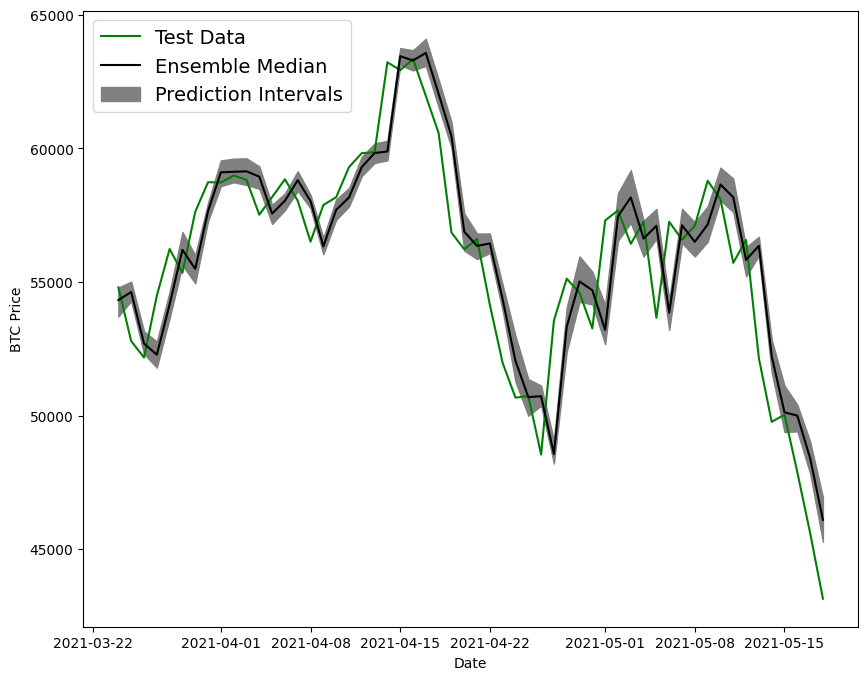

In [146]:
# Plotting The Predictions and Lower and Upper Bounds of Predictions:

# Get the median values of our ensemble preds
ensemble_median = np.median(ensemble_preds, axis=0)

# Plot the median of our ensemble preds along with the prediction intervals (where the predictions fall between)
offset=500
plt.figure(figsize=(10, 8))
plt.plot(X_test.index[offset:], y_test[offset:], 'g', label= 'Test Data')
plt.plot(X_test.index[offset:], ensemble_median[offset:], 'k-', label= 'Ensemble Median')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.fill_between(X_test.index[offset:], 
                 (lower)[offset:], 
                 (upper)[offset:], label='Prediction Intervals', color= 'grey')
plt.legend(loc='upper left', fontsize=14);

We've just plotted:
* The test data (the ground truth Bitcoin prices)
* The median of the ensemble predictions 
* The 95% prediction intervals (assuming the data is Gaussian/normal, the model is saying that 95% of the time, predicted value should fall between this range)

What can you tell about the ensemble model from the plot above?

It looks like the ensemble predictions are lagging slightly behind the actual data.

And the prediction intervals are fairly low throughout.

The combination of lagging predictions as well as low prediction intervals indicates that our ensemble model may be **overfitting** the data, meaning it's basically replicating what a naïve model would do and just predicting the previous timestep value for the next value.

This would explain why previous attempts to beat the naïve forecast have been futile.

We can test this hypothesis of overfitting by creating a model to make predictions into the future and seeing what they look like.

> 🔑 **Note:** Our prediction intervals assume that the data we're using come from a Gaussian/normal distribution (also called a bell curve), however, open systems rarely follow the Gaussian.

## Aside: two types of uncertainty (coconut and subway)

For many things, future predictions are helpful. Such as knowing the bus you're trying to catch to the library leaves at 10:08am. The time 10:08am is a **point prediction**, if the bus left at a random time every day, how helpful would it be?

Just like saying the price of Bitcoin tomorrow will be 50,000USD is a point prediction.

However, as we've discussed knowing a **prediction interval** or **uncertainty estimate** can be as helpful or even more helpful than a point prediction itself.

Uncertainty estimates seek out to qualitatively and quantitatively answer the questions:
* What can my model know? (with perfect data, what's possible to learn?)
* What doesn't my model know? (what can a model never predict?)

There are two types of uncertainty in machine learning you should be aware of:

* **Aleatoric uncertainty** - this type of uncertainty cannot be reduced, it is also referred to as "data" or "subway" uncertainty.
  * Let's say your train is scheduled to arrive at 10:08am but very rarely does it arrive at *exactly* 10:08am. You know it's usually a minute or two either side and perhaps up to 10-minutes late if traffic is bad. Even with all the data you could imagine, this level of uncertainty is still going to be present (much of it being noise).
  * When we measured prediction intervals, we were measuring a form of subway uncertainty for Bitcoin price predictions (a little either side of the point prediction).

* **Epistemic uncertainty** - this type of uncertainty can be reduced, it is also referred to as "model" or "coconut" uncertainty, it is very hard to calculate.
  * The analogy for coconut uncertainty involves whether or not you'd get hit on the head by a coconut when going to a beach. 
    * If you were at a beach with coconuts trees, as you could imagine, this would be very hard to calculate. How often does a coconut fall of a tree? Where are you standing? 
    * But you could reduce this uncertainty to zero by going to a beach without coconuts (collect more data about your situation).
  * Model uncertainty can be reduced by collecting more data samples/building a model to capture different parameters about the data you're modelling.

The lines between these are blurred (one type of uncertainty can change forms into the other) and they can be confusing at first but are important to keep in mind for any kind of time series prediction.

If you ignore the uncertanties, are you really going to get a reliable prediction?

Perhaps another example might help.


### Learning more on uncertainty

The field of quantifying uncertainty estimation in machine learning is a growing area of research.

If you'd like to learn more I'd recommend the following.

> 📖 **Resources:** Places to learn more about uncertainty in machine learning/forecasting:
* 🎥 [MIT 6.S191: Evidential Deep Learning and Uncertainty](https://youtu.be/toTcf7tZK8c) 
* [Uncertainty quantification on Wikipedia](https://en.wikipedia.org/wiki/Uncertainty_quantification#Aleatoric_and_epistemic_uncertainty)
* [*Why you should care about the Nate Silver vs. Nassim Taleb Twitter war*](https://towardsdatascience.com/why-you-should-care-about-the-nate-silver-vs-nassim-taleb-twitter-war-a581dce1f5fc) by Isaac Faber - a great insight into the role of uncertainty in the example of election prediction. 
* [*3 facts about time series forecasting that surprise experienced machine learning practitioners*](https://towardsdatascience.com/3-facts-about-time-series-forecasting-that-surprise-experienced-machine-learning-practitioners-69c18ee89387) by Skander Hannachi - fantastic outline of some of the main mistakes people make when building forecasting models, especially forgetting about uncertainty estimates.
* [*Engineering Uncertainty Estimation in Neural Networks for Time Series Prediction at Uber*](https://eng.uber.com/neural-networks-uncertainty-estimation/) - a discussion on techniques Uber used to engineer uncertainty estimates into their time sereis neural networks.

## Model 9: Train a model on the full historical data to make predictions into future

To make predictions into the future, we'll train a model on the full dataset and then get to make predictions to some future horizon.

Why use the full dataset?

Previously, we split our data into training and test sets to evaluate how our model did on pseudo-future data (the test set).

But since the goal of a forecasting model is to predict values into the actual-future, we won't be using a test set.

> 🔑 **Note:** Forecasting models need to be retrained every time a forecast is made. Why? Because if Bitcoin prices are updated daily and you predict the price for tomorrow. Your model is only really valid for one day. When a new price comes out (e.g. the next day), you'll have to retrain your model to incorporate that new price to predict the next forecast.

In [147]:
bitcoin_prices_windowed.head(10)

,Price,Block_Reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2013-10-01,123.65499,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,25,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,25,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,25,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,25,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN
2013-10-06,120.65533,25,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN
2013-10-07,121.79500,25,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN
2013-10-08,123.03300,25,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,25,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500


In [152]:
# Train Model on Entire Data to Make Prediction for the Next Day:
X_all = bitcoin_prices_windowed.dropna().drop(['Price', 'Block_Reward'], axis= 1).to_numpy()
y_all = bitcoin_prices_windowed.dropna()['Price'].to_numpy()

In [153]:
X_all[:5]

array([[121.795  , 120.65533, 121.33866, 118.67466, 108.58483, 125.455  ,
        123.65499],
       [123.033  , 121.795  , 120.65533, 121.33866, 118.67466, 108.58483,
        125.455  ],
       [124.049  , 123.033  , 121.795  , 120.65533, 121.33866, 118.67466,
        108.58483],
       [125.96116, 124.049  , 123.033  , 121.795  , 120.65533, 121.33866,
        118.67466],
       [125.27966, 125.96116, 124.049  , 123.033  , 121.795  , 120.65533,
        121.33866]])

In [154]:
y_all[:5]

array([123.033  , 124.049  , 125.96116, 125.27966, 125.9275 ])

Let's turn Data into Performance Optimized TensorFlow Datasets by:
1. Turning `X_all` and `y_all` into tensor Datasets using [`tf.data.Dataset.from_tensor_slices()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices)
2. Combining the features and labels into a Dataset tuple using [`tf.data.Dataset.zip()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#zip)
3. Batch and prefetch the data using [`tf.data.Dataset.batch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch) and [`tf.data.Dataset.prefetch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch) respectively

In [155]:
# 1. Turn x and y into Tensor Datasets:
features_dataset_all = tf.data.Dataset.from_tensor_slices(X_all)
labels_dataset_all = tf.data.Dataset.from_tensor_slices(y_all)

# 2. Combine features & labels:
dataset_all = tf.data.Dataset.zip((features_dataset_all, labels_dataset_all))

# 3. Batch and prefetch for optimal performance
BATCH_SIZE= 1024
dataset_all = dataset_all.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [156]:
# Creating The Model:
tf.random.set_seed(42)

model_9 = Sequential(name= 'Model_9_Simple_Desne')
model_9.add(Dense(units= 128, activation= 'relu'))
model_9.add(Dense(units= 128, activation= 'relu'))
model_9.add(Dense(units= HORIZON))

# Compiling The Model:
model_9.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_9_history = model_9.fit(dataset_all,
                             epochs= 100)

Epoch 1/100
3/3 [==============================] - 1s 6ms/step - loss: 3833.6050 - mae: 3833.6050
Epoch 2/100
3/3 [==============================] - 0s 5ms/step - loss: 1559.6053 - mae: 1559.6053
Epoch 3/100
3/3 [==============================] - 0s 7ms/step - loss: 756.4907 - mae: 756.4907
Epoch 4/100
3/3 [==============================] - 0s 8ms/step - loss: 1096.6808 - mae: 1096.6808
Epoch 5/100
3/3 [==============================] - 0s 6ms/step - loss: 553.6335 - mae: 553.6335
Epoch 6/100
3/3 [==============================] - 0s 6ms/step - loss: 581.2332 - mae: 581.2332
Epoch 7/100
3/3 [==============================] - 0s 5ms/step - loss: 717.2815 - mae: 717.2815
Epoch 8/100
3/3 [==============================] - 0s 6ms/step - loss: 423.8792 - mae: 423.8792
Epoch 9/100
3/3 [==============================] - 0s 6ms/step - loss: 510.0591 - mae: 510.0591
Epoch 10/100
3/3 [==============================] - 0s 5ms/step - loss: 497.3172 - mae: 497.3172
Epoch 11/100
3/3 [===============

### Make predictions on the future

As we've seen so far, our machine learning models have performed quite poorly at predicting the price of Bitcoin (time series forecasting in open systems is typically a game of luck), often worse than the naive forecast.

That doesn't mean we can't use our models to *try* and predict into the future.

To do so, let's start by defining a variable `INTO_FUTURE` which decides how many timesteps we'd like to predict into the future.

![flowchart representation prediction loop to make forecasts and then append forecasts to data and make more forecasts continuously until forecast horizon is exhausted](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-prediction-loop-for-forecasts.png)
*Example flow chart representing the loop we're about to create for making forecasts. Not pictured: retraining a forecasting model every time a forecast is made & new data is acquired. For example, if you're predicting the price of Bitcoin daily, you'd want to retrain your model every day, since each day you're going to have a new data point to work with.*

Alright, let's create a function which returns `INTO_FUTURE` forecasted values using a trained model.

To do so, we'll build the following steps:
1. Function which takes as input: 
  * a list of values (the Bitcoin historical data)
  * a trained model (such as `model_9`)
  * a window into the future to predict (our `INTO_FUTURE` variable)
  * the window size a model was trained on (`WINDOW_SIZE`) - the model can only predict on the same kind of data it was trained on
2. Creates an empty list for future forecasts (this will be returned at the end of the function) and extracts the last `WINDOW_SIZE` values from the input values (predictions will start from the last `WINDOW_SIZE` values of the training data)
3. Loop `INTO_FUTURE` times making a prediction on `WINDOW_SIZE` datasets which update to remove the first the value and append the latest prediction 
  * Eventually future predictions will be made using the model's own previous predictions as input

In [157]:
# How many timesteps to predict into the future?
INTO_FUTURE = 14 # since our Bitcoin data is daily, this is for 14 days

In [158]:
# 1. Create Function to Make Predictions Into The Future:
def make_future_forecast(values, model, into_future, window_size= WINDOW_SIZE) -> list:
    """
    Makes future forecasts into_future steps after values ends.

    Returns future forecasts as list of floats.
    """

    # 2. Make an Empty List for Future Forecasts/Prepare Data to Forecast On:
    future_forecast = []
    last_window = values[-window_size:] # only want preds from the last window (this will get updated)

    # 3. Make INTO_FUTURE Number of Predictions, Altering The Data Which Gets Predicted on Each Time:
    for _ in range(into_future):

        # Predict on last window then append it again, again, again (model starts to make forecasts on its own forecasts)
        future_pred = model.predict(tf.expand_dims(last_window, axis= 0))
        print(f'Predicting on: \n {last_window} -> Prediction: {tf.squeeze(future_pred).numpy()}\n')

        # Append Predictions to future_forecast:
        future_forecast.append(tf.squeeze(future_pred).numpy())

        # Update last window with new pred and get WINDOW_SIZE most recent preds (model was trained on WINDOW_SIZE windows):
        last_window = np.append(last_window, future_pred)[-window_size:]

    return future_forecast

In [159]:
# Making Forecasts into Future of The Price of Bitcoin:
future_forecast = make_future_forecast(values= y_all,
                                      model= model_9,
                                      into_future= INTO_FUTURE,
                                      window_size= WINDOW_SIZE)

1/1 [==============================] - 0s 45ms/step
Predicting on: 
 [56573.5554719  52147.82118698 49764.1320816  50032.69313676
 47885.62525472 45604.61575361 43144.47129086] -> Prediction: 55407.75

1/1 [==============================] - 0s 17ms/step
Predicting on: 
 [52147.82118698 49764.1320816  50032.69313676 47885.62525472
 45604.61575361 43144.47129086 55407.75      ] -> Prediction: 49947.2109375

1/1 [==============================] - 0s 16ms/step
Predicting on: 
 [49764.1320816  50032.69313676 47885.62525472 45604.61575361
 43144.47129086 55407.75       49947.2109375 ] -> Prediction: 50488.65625

1/1 [==============================] - 0s 14ms/step
Predicting on: 
 [50032.69313676 47885.62525472 45604.61575361 43144.47129086
 55407.75       49947.2109375  50488.65625   ] -> Prediction: 49034.359375

1/1 [==============================] - 0s 16ms/step
Predicting on: 
 [47885.62525472 45604.61575361 43144.47129086 55407.75
 49947.2109375  50488.65625    49034.359375  ] -> Predic

In [160]:
future_forecast

[55407.75,
 49947.21,
 50488.656,
 49034.36,
 45082.4,
 44962.11,
 49411.797,
 52750.555,
 50195.766,
 50091.367,
 46175.203,
 44492.703,
 47309.414,
 50987.324]

### Plot future forecasts

To plot our model's future forecasts against the historical data of Bitcoin, we're going to need a series of future dates (future dates from the final date of where our dataset ends).

How about we create a function to return a date range from some specified start date to a specified number of days into the future (`INTO_FUTURE`).

To do so, we'll use a combination of NumPy's [`datetime64` datatype](https://numpy.org/doc/stable/reference/arrays.datetime.html) (our Bitcoin dates are already in this datatype) as well as NumPy's `timedelta64` method which helps to create date ranges.

In [161]:
def get_future_dates(start_date, into_future, offset=1):
  """
  Returns array of datetime values from ranging from start_date to start_date+horizon.

  start_date: date to start range (np.datetime64)
  into_future: number of days to add onto start date for range (int)
  offset: number of days to offset start_date by (default 1)
  """
  start_date = start_date + np.timedelta64(offset, 'D') # specify start date, "D" stands for day
  end_date = start_date + np.timedelta64(into_future, 'D') # specify end date
  return np.arange(start_date, end_date, dtype= 'datetime64[D]') # return a date range between start date and end date

The start date of our forecasted dates will be the last date of our dataset. 

In [162]:
# Last timestep of timesteps (currently in np.datetime64 format)
last_timestep = bitcoin_prices.index[-1]
last_timestep

Timestamp('2021-05-18 00:00:00')

In [163]:
# Get next two weeks of timesteps
next_time_steps = get_future_dates(start_date=last_timestep, 
                                   into_future=INTO_FUTURE)
next_time_steps

array(['2021-05-19', '2021-05-20', '2021-05-21', '2021-05-22',
       '2021-05-23', '2021-05-24', '2021-05-25', '2021-05-26',
       '2021-05-27', '2021-05-28', '2021-05-29', '2021-05-30',
       '2021-05-31', '2021-06-01'], dtype='datetime64[D]')

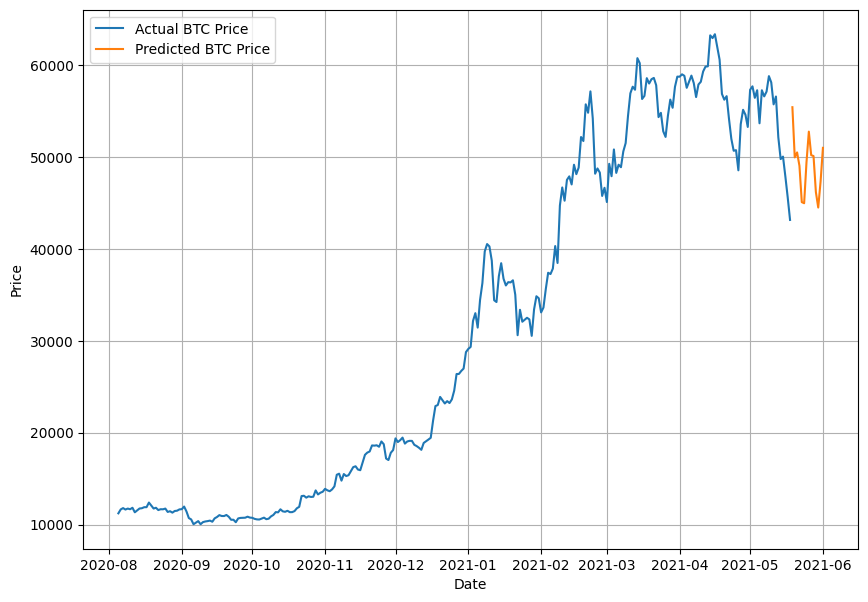

In [164]:
# Plot future price predictions of Bitcoin
plt.figure(figsize=(10, 7))
plot_time_series(bitcoin_prices.index, btc_price, start=2500, format= '-', labels= 'Actual BTC Price')
plot_time_series(next_time_steps, future_forecast, format= '-', labels= 'Predicted BTC Price')

To make sure the lines of the plot connect , let's insert the last timestep and Bitcoin price of our training data to the `next_time_steps` and `future_forecast` arrays.

In [165]:
# Insert last timestep/final price so the graph doesn't look messed
next_time_steps = np.insert(next_time_steps, 0, last_timestep)
future_forecast = np.insert(future_forecast, 0, btc_price[-1])
next_time_steps, future_forecast

(array(['2021-05-18', '2021-05-19', '2021-05-20', '2021-05-21',
        '2021-05-22', '2021-05-23', '2021-05-24', '2021-05-25',
        '2021-05-26', '2021-05-27', '2021-05-28', '2021-05-29',
        '2021-05-30', '2021-05-31', '2021-06-01'], dtype='datetime64[D]'),
 array([43144.473, 55407.75 , 49947.21 , 50488.656, 49034.36 , 45082.4  ,
        44962.11 , 49411.797, 52750.555, 50195.766, 50091.367, 46175.203,
        44492.703, 47309.414, 50987.324], dtype=float32))

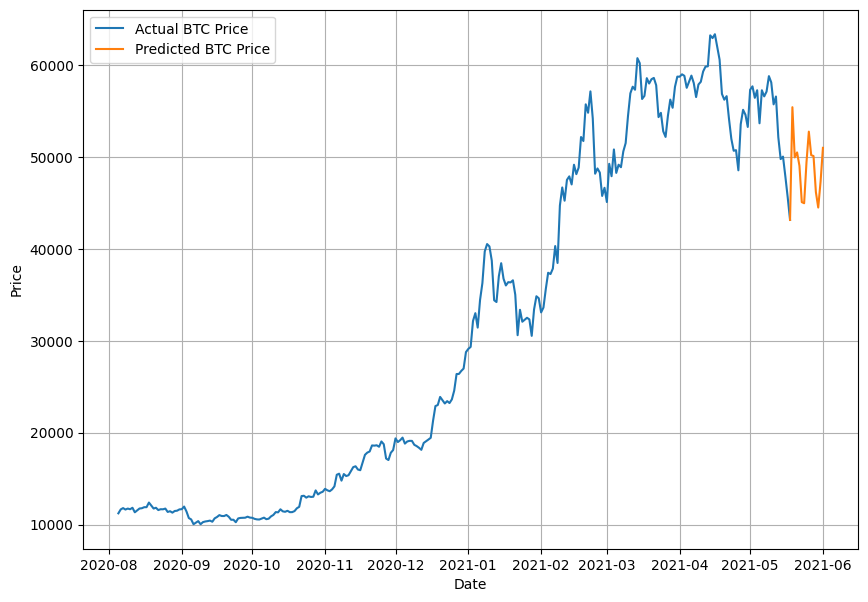

In [166]:
# Plot future price predictions of Bitcoin
plt.figure(figsize=(10, 7))
plot_time_series(bitcoin_prices.index, btc_price, start=2500, format= '-', labels= 'Actual BTC Price')
plot_time_series(next_time_steps, future_forecast, format= '-', labels= 'Predicted BTC Price')

It looks like our predictions are starting to form a bit of a cyclic pattern (up and down in the same way).

Perhaps that's due to our model overfitting the training data and not generalizing well for future data. Also, as you could imagine, the further you predict into the future, the higher your chance for error (try seeing what happens when you predict 100 days into the future).

But of course, we can't measure these predictions as they are because after all, they're predictions into the actual-future.